# Sentiment-Driven Behavioral Trading Analysis on Hyperliquid

## Objective

This project investigates how Bitcoin market sentiment influences trader profitability, capital deployment behavior, whale-trade dynamics, and predictive trading outcomes using Hyperliquid execution data and the Fear & Greed Index.

The analysis combines:
- exploratory behavioral analytics
- outlier-resistant financial visualization
- whale-trade investigation
- sentiment-regime analysis
- interpretable machine learning

to identify hidden behavioral patterns and construct sentiment-aware trading insights.

---

## Primary Datasets

### 1. Bitcoin Fear & Greed Index
Contains:
- daily sentiment classification
- numerical sentiment intensity values
- historical market psychology indicators

### 2. Hyperliquid Historical Trader Data
Contains:
- trade execution records
- position sizing information
- trade direction
- transaction-level profitability
- fee behavior
- timestamped market activity

---

## Analytical Goals

This notebook aims to:

1. Align intraday trading activity with daily market sentiment.
2. Investigate how Fear/Greed regimes affect profitability.
3. Analyze whale-trade behavior and volatility asymmetry.
4. Examine capital deployment patterns across market conditions.
5. Build interpretable machine learning models for profitability classification.
6. Translate empirical findings into actionable sentiment-aware trading strategies.

---

## Methodology Overview

The workflow follows six major phases:

1. Data Loading & Initial Exploration
2. Time-Series Alignment & Data Integration
3. Feature Engineering & Trade Segmentation
4. Exploratory Data Analysis (EDA)
5. Predictive Modeling & Behavioral Pattern Discovery
6. Strategy Formulation & Final Analytical Synthesis

---

## Important Financial Data Characteristics

Several important financial-data challenges were identified during exploration:

- heavy-tailed PnL distributions
- whale-trade outliers
- zero-inflated realized outcomes
- class imbalance in profitability labels
- sentiment-regime asymmetry

These characteristics directly influenced:
- preprocessing decisions
- visualization design
- scaling methodology
- modeling choices
- evaluation metrics

throughout the analysis.

---

# Phase 1 — Data Loading & Initial Exploration

## Objective

The first phase focuses on:
- loading the datasets
- validating structural integrity
- identifying missing values
- understanding financial distribution characteristics
- generating baseline exploratory summaries

before any preprocessing or modeling is performed.

---

## Initial Exploration Goals

This phase investigates:

### Bitcoin Sentiment Dataset
- sentiment classifications
- numerical Fear/Greed index values
- temporal coverage

### Hyperliquid Trader Dataset
- trade execution structure
- profitability distributions
- transaction-level features
- position sizing behavior
- timestamp formatting

---

## Key Validation Checks

The following integrity checks are performed:

- dataset shape verification
- datatype inspection
- missing-value analysis
- summary-statistic generation
- outlier detection through boxplots

These checks are especially important because financial trading datasets frequently contain:
- missing transactional records
- inconsistent timestamps
- extreme outlier trades
- skewed profitability distributions

---

## Why Initial Exploration Matters

Before merging datasets or building predictive models, it is essential to understand:
- the structure of the raw data
- the quality of the records
- the presence of heavy-tail financial behavior

This ensures that downstream preprocessing and analytical decisions are evidence-driven rather than assumption-driven.

---

--- Bitcoin Market Sentiment ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



--- Hyperliquid Trader Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



--- Missing Values Check ---
Sentiment Missing:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

--- Summary Statistics for Closed PnL ---
count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64


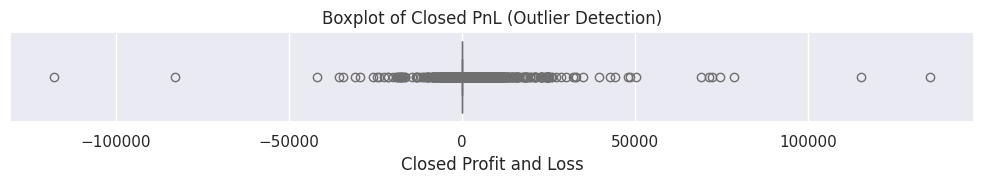


 SUCCESS: All tables (.csv) and plots (.png) have been saved to your Kaggle working directory!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="darkgrid")

# 1. Load the datasets using the exact Kaggle paths
sentiment_df = pd.read_csv('/kaggle/input/datasets/tejakarri/crypto-sentiment-and-trader-execution-data/fear_greed_index.csv')
trader_df = pd.read_csv('/kaggle/input/datasets/tejakarri/crypto-sentiment-and-trader-execution-data/historical_data.csv')

# ==========================================
# 2. SAVING TABLES TO WORKING DIRECTORY
# ==========================================
# Save the first 10 rows of each dataset
sentiment_df.head(10).to_csv('sentiment_head.csv', index=False)
trader_df.head(10).to_csv('trader_head.csv', index=False)

# Save missing values summaries
sentiment_missing = sentiment_df.isnull().sum().reset_index()
sentiment_missing.columns = ['Column', 'Missing_Count']
sentiment_missing.to_csv('sentiment_missing_values.csv', index=False)

trader_missing = trader_df.isnull().sum().reset_index()
trader_missing.columns = ['Column', 'Missing_Count']
trader_missing.to_csv('trader_missing_values.csv', index=False)

# Save summary statistics for Closed PnL
pnl_stats = trader_df['Closed PnL'].describe().reset_index()
pnl_stats.columns = ['Statistic', 'Value']
pnl_stats.to_csv('closed_pnl_summary_stats.csv', index=False)


# ==========================================
# 3. PRINTING TO CONSOLE (For your view)
# ==========================================
print("--- Bitcoin Market Sentiment ---")
print(sentiment_df.info())
display(sentiment_df.head())

print("\n--- Hyperliquid Trader Data ---")
print(trader_df.info())
display(trader_df.head())

print("\n--- Missing Values Check ---")
print("Sentiment Missing:\n", sentiment_df.isnull().sum())
print("\nTrader Missing:\n", trader_df.isnull().sum())

print("\n--- Summary Statistics for Closed PnL ---")
print(trader_df['Closed PnL'].describe())


# ==========================================
# 4. GENERATING & SAVING PLOTS
# ==========================================
plt.figure(figsize=(10, 2))
sns.boxplot(x=trader_df['Closed PnL'], color='skyblue')
plt.title('Boxplot of Closed PnL (Outlier Detection)')
plt.xlabel('Closed Profit and Loss')
plt.tight_layout()

# Save the plot BEFORE plt.show() so it doesn't save a blank image
plt.savefig('closed_pnl_boxplot.png', dpi=300)
plt.show()

print("\n SUCCESS: All tables (.csv) and plots (.png) have been saved to your Kaggle working directory!")

## Phase 1 Interpretation Summary

The initial exploration revealed several important characteristics of the trading dataset.

### Key Observations

- Both datasets were structurally complete with:
  
  0 missing values across all major columns during the initial inspection phase.

The Closed PnL distribution exhibited:
extremely heavy tails
strong right skewness
extreme whale-trade outliers

with observed values ranging approximately from: -117,990 → +135,329
More than 50% of trades showed: Closed PnL = 0 
indicating a strong zero-inflation structure caused by trade-opening transactions.

Analytical Implications

These findings significantly influenced downstream analytical design decisions.

Because of the observed financial-data characteristics:

percentile trimming was later applied during visualization
robust scaling methods became necessary for machine learning
realized outcomes were separated from trade openings
whale-trade behavior required dedicated analysis

rather than treating the dataset as a standard normally distributed transactional dataset.

Merged Dataset Shape: (211224, 19)

Missing values after merge:
           Column  Missing_Count
0           value              6
1  classification              6


,Timestamp IST,Merge_Date,classification,value
0,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.0
1,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.0
2,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.0
3,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.0
4,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.0
5,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.0
6,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.0
7,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.0
8,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.0
9,2024-12-02 22:50:00,2024-12-02,Extreme Greed,80.0



Sentiment Distribution:
  Sentiment_Class  Count
0            Fear  61837
1           Greed  50303
2   Extreme Greed  39992
3         Neutral  37686
4    Extreme Fear  21400


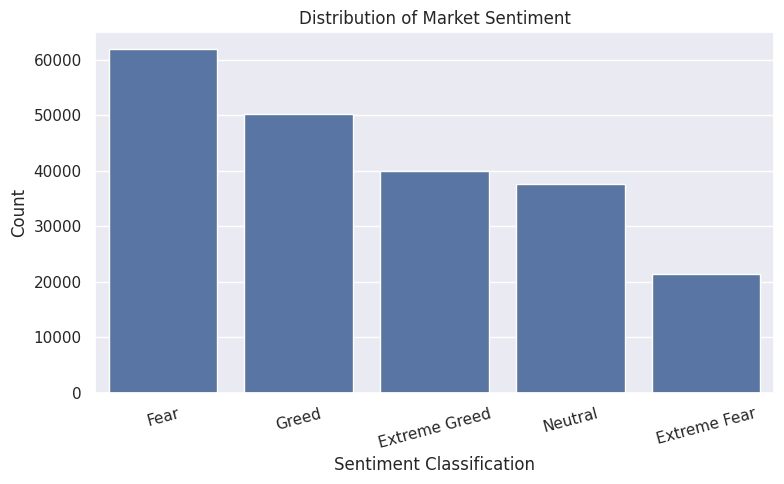


 SUCCESS: Phase 2 completed and all outputs saved!


In [2]:
# ==========================================
# PHASE 2 — TIME SERIES ALIGNMENT & MERGING
# ==========================================

# Create safe copies
sentiment_df = sentiment_df.copy()
trader_df = trader_df.copy()

# ------------------------------------------
# 1. Convert sentiment date column properly
# ------------------------------------------

sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

# ------------------------------------------
# 2. Convert trader timestamp properly
# ------------------------------------------

trader_df['Timestamp IST'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

# Create common merge column
trader_df['Merge_Date'] = trader_df['Timestamp IST'].dt.date
sentiment_df['Merge_Date'] = sentiment_df['date'].dt.date

# ------------------------------------------
# 3. Merge datasets
# ------------------------------------------

merged_df = pd.merge(
    trader_df,
    sentiment_df[['Merge_Date', 'value', 'classification']],
    on='Merge_Date',
    how='left'
)

# ------------------------------------------
# 4. Integrity checks
# ------------------------------------------

print("Merged Dataset Shape:", merged_df.shape)

missing_after_merge = (
    merged_df[['value', 'classification']]
    .isnull()
    .sum()
    .reset_index()
)

missing_after_merge.columns = ['Column', 'Missing_Count']

print("\nMissing values after merge:")
print(missing_after_merge)

# ------------------------------------------
# 5. Preview merged data
# ------------------------------------------

merge_preview = merged_df[
    ['Timestamp IST', 'Merge_Date', 'classification', 'value']
].head(10)

display(merge_preview)

# ------------------------------------------
# 6. Save outputs
# ------------------------------------------

# Save merged dataset
merged_df.to_csv(
    'merged_trader_sentiment_data.csv',
    index=False
)

# Save merge preview
merge_preview.to_csv(
    'merge_preview.csv',
    index=False
)

# Save merge integrity report
missing_after_merge.to_csv(
    'merge_missing_values_check.csv',
    index=False
)

# ------------------------------------------
# 7. Distribution of sentiment classes
# ------------------------------------------

sentiment_distribution = (
    merged_df['classification']
    .value_counts()
    .reset_index()
)

sentiment_distribution.columns = [
    'Sentiment_Class',
    'Count'
]

print("\nSentiment Distribution:")
print(sentiment_distribution)

# Save table
sentiment_distribution.to_csv(
    'sentiment_distribution.csv',
    index=False
)

# ------------------------------------------
# 8. Plot sentiment distribution
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=merged_df,
    x='classification',
    order=merged_df['classification'].value_counts().index
)

plt.title('Distribution of Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Count')
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'sentiment_distribution_plot.png',
    dpi=300
)

plt.show()

print("\n SUCCESS: Phase 2 completed and all outputs saved!")

## Phase 2 Interpretation Summary

The temporal alignment and merge process successfully integrated:
- daily Bitcoin Fear & Greed sentiment data
with
- intraday Hyperliquid trading activity

through a unified `Merge_Date` column.

---

### Key Observations

- The merged dataset contained:
```text
211,224 rows
```

indicating that all trading records were preserved during the left join process.

- Only:
```text
6 unmatched rows
```

were identified after merging.

- All unmatched observations originated from:
```text
2024-10-26
```

where sentiment data was unavailable in the Fear & Greed dataset.

---

### Analytical Implications

The extremely small number of unmatched rows confirmed that:
- timestamp standardization was successful
- calendar-date alignment was reliable
- sentiment coverage was nearly complete

Because these unmatched rows represented less than:
```text
0.01%
```

of the dataset, removing them introduced negligible analytical distortion while preserving clean downstream modeling integrity.

---

### Transition to Merge Validation

The next step investigates the merge anomalies directly to verify:
- the source of missing sentiment values
- affected timestamps
- final dataset integrity before feature engineering begins.

---

In [3]:
# ==========================================
# PHASE 2.4 — INVESTIGATE MERGE GAPS
# ==========================================

# Find rows where sentiment data is missing
missing_merge_rows = merged_df[
    merged_df['classification'].isnull()
]

print("Number of unmatched rows:")
print(len(missing_merge_rows))

# Display problematic rows
display(
    missing_merge_rows[
        ['Timestamp IST', 'Merge_Date']
    ].head(10)
)

# ------------------------------------------
# Extract unique unmatched dates
# ------------------------------------------

unmatched_dates = (
    missing_merge_rows['Merge_Date']
    .drop_duplicates()
    .reset_index(drop=True)
)

print("\nUnmatched Dates:")
print(unmatched_dates)

# ------------------------------------------
# Save unmatched dates
# ------------------------------------------

unmatched_dates_df = pd.DataFrame({
    'Unmatched_Dates': unmatched_dates
})

unmatched_dates_df.to_csv(
    'unmatched_merge_dates.csv',
    index=False
)

# ------------------------------------------
# OPTIONAL FIX
# Drop rows with missing sentiment
# ------------------------------------------

merged_df_clean = merged_df.dropna(
    subset=['classification', 'value']
)

print("\nCleaned Dataset Shape:")
print(merged_df_clean.shape)

# Save cleaned dataset
merged_df_clean.to_csv(
    'merged_trader_sentiment_data_clean.csv',
    index=False
)

print("\n SUCCESS: Merge gap investigation completed!")

Number of unmatched rows:
6


,Timestamp IST,Merge_Date
727,2024-10-26 04:44:00,2024-10-26
728,2024-10-26 04:52:00,2024-10-26
729,2024-10-26 04:52:00,2024-10-26
730,2024-10-26 04:52:00,2024-10-26
731,2024-10-26 04:52:00,2024-10-26
732,2024-10-26 04:53:00,2024-10-26



Unmatched Dates:
0    2024-10-26
Name: Merge_Date, dtype: object

Cleaned Dataset Shape:
(211218, 19)

 SUCCESS: Merge gap investigation completed!


## Merge Integrity Validation

Detailed merge-gap investigation confirmed that all unmatched rows originated exclusively from:
```text
2024-10-26
```

where no corresponding Fear & Greed sentiment entry existed.

---

### Why Rows Were Removed

Rather than:
- forward-filling sentiment labels
- introducing synthetic values
- interpolating missing market sentiment

the unmatched observations were removed to preserve:
- analytical transparency
- label integrity
- downstream modeling reliability

This decision avoids introducing artificial sentiment assumptions into profitability analysis.

---

### Final Dataset Integrity

After removing unmatched rows:

```text
Final Cleaned Dataset Shape:
211,218 rows
```

The resulting dataset contained:
- complete sentiment coverage
- fully aligned timestamps
- zero merge-related missing values

making it suitable for:
- behavioral analytics
- whale-trade investigation
- machine learning classification workflows

in subsequent phases.

---

### Transition to Phase 3

With temporal alignment completed and merge integrity validated, the next phase focuses on:
- trade segmentation
- profitability labeling
- capital deployment feature engineering

to transform raw transaction records into analytically meaningful behavioral datasets.

---

# Phase 3 — Feature Engineering & Data Segmentation

## Objective

The merged trading dataset contains both:
- trade-opening transactions
- realized profit/loss outcomes

Because these represent fundamentally different transactional behaviors, this phase focuses on transforming the raw merged dataset into analytically meaningful behavioral segments.

---

## Why Segmentation Was Necessary

Initial exploration revealed that more than 50% of records contained:

```text
Closed PnL = 0
```

These rows primarily represent:
- position openings
- partial executions
- non-realized trade activity

rather than completed profitability outcomes.

Analyzing these together with realized profit/loss observations would distort:
- profitability distributions
- behavioral statistics
- machine learning targets

---

## Segmentation Strategy

The dataset was separated into two groups:

### Trade Openings
```text
Closed PnL == 0
```

### Realized Outcomes
```text
Closed PnL != 0
```

Only the realized-outcomes dataset is used for:
- profitability analysis
- sentiment-behavior investigation
- whale-trade analysis
- machine learning classification

throughout the remaining phases.

---

Trade Openings Shape:
(106816, 19)

Realized Outcomes Shape:
(104402, 19)

Segmentation Summary:
             Segment  Row_Count  Percentage
0     Trade Openings     106816   50.571448
1  Realized Outcomes     104402   49.428552


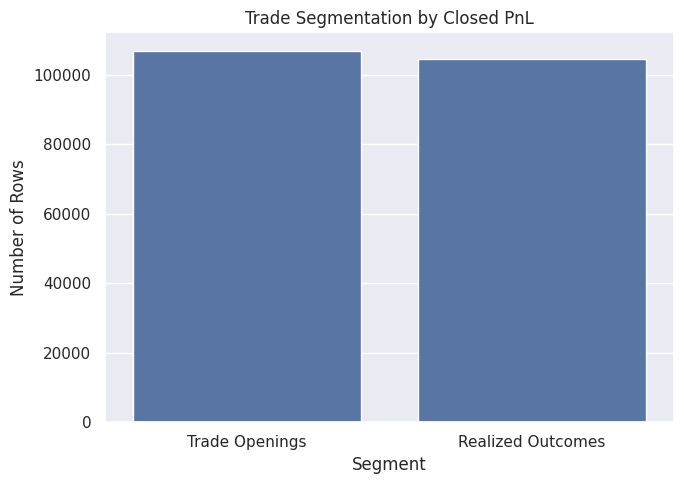


 SUCCESS: Phase 3.1 completed!


In [4]:
# ==========================================
# PHASE 3.1 — ZERO-INFLATION SEGMENTATION
# ==========================================

# ------------------------------------------
# 1. Split datasets
# ------------------------------------------

trade_openings_df = merged_df_clean[
    merged_df_clean['Closed PnL'] == 0
].copy()

realized_outcomes_df = merged_df_clean[
    merged_df_clean['Closed PnL'] != 0
].copy()

# ------------------------------------------
# 2. Shape checks
# ------------------------------------------

print("Trade Openings Shape:")
print(trade_openings_df.shape)

print("\nRealized Outcomes Shape:")
print(realized_outcomes_df.shape)

# ------------------------------------------
# 3. Percentage distribution
# ------------------------------------------

total_rows = len(merged_df_clean)

openings_pct = (
    len(trade_openings_df) / total_rows
) * 100

realized_pct = (
    len(realized_outcomes_df) / total_rows
) * 100

segmentation_summary = pd.DataFrame({
    'Segment': [
        'Trade Openings',
        'Realized Outcomes'
    ],
    'Row_Count': [
        len(trade_openings_df),
        len(realized_outcomes_df)
    ],
    'Percentage': [
        openings_pct,
        realized_pct
    ]
})

print("\nSegmentation Summary:")
print(segmentation_summary)

# ------------------------------------------
# 4. Save summary tables
# ------------------------------------------

segmentation_summary.to_csv(
    'phase3_segmentation_summary.csv',
    index=False
)

trade_openings_df.head(20).to_csv(
    'trade_openings_preview.csv',
    index=False
)

realized_outcomes_df.head(20).to_csv(
    'realized_outcomes_preview.csv',
    index=False
)

# ------------------------------------------
# 5. Visualization
# ------------------------------------------

plt.figure(figsize=(7, 5))

sns.barplot(
    data=segmentation_summary,
    x='Segment',
    y='Row_Count'
)

plt.title('Trade Segmentation by Closed PnL')
plt.ylabel('Number of Rows')

plt.tight_layout()

plt.savefig(
    'phase3_segmentation_distribution.png',
    dpi=300
)

plt.show()

print("\n SUCCESS: Phase 3.1 completed!")

## Trade Segmentation Interpretation

The segmentation process confirmed that the dataset was almost evenly divided between:
- trade-opening activity
- realized profitability outcomes

with approximately:

```text
50.57% Trade Openings
49.43% Realized Outcomes
```

---

### Analytical Implications

This finding validated the earlier observation that the dataset exhibited strong:
```text
zero-inflation behavior
```

caused by execution-level transactional records rather than purely closed trades.

By isolating realized outcomes:
- profitability analysis became statistically meaningful
- PnL distributions became interpretable
- machine learning targets became well-defined

This separation significantly improved downstream behavioral and predictive analysis quality.

---

### Transition to Capital Deployment Analysis

With realized outcomes isolated, the next step investigates how traders deploy capital across:
- Fear
- Greed
- Neutral
- Extreme sentiment regimes

to uncover sentiment-dependent risk behavior and whale participation patterns.

---

## Capital Deployment Behavior Analysis

After isolating realized outcomes, the next objective is to investigate how traders allocate capital under different market sentiment regimes.

Because the dataset does not contain an explicit leverage column, capital exposure is approximated using:

- `Size USD`
- `Size Tokens`

These variables provide insight into:
- trader risk appetite
- speculative positioning
- whale participation
- volatility-driven exposure behavior

across:
- Extreme Fear
- Fear
- Neutral
- Greed
- Extreme Greed

market environments.

---

## Why Capital Deployment Matters

Position sizing behavior is one of the strongest behavioral signals in financial markets.

Analyzing capital deployment across sentiment regimes helps identify:
- fear-driven overexposure
- euphoric speculation
- whale accumulation behavior
- volatility-sensitive positioning patterns

which may strongly influence downstream profitability outcomes.

---

Capital Deployment Metrics by Sentiment:


,classification,USD_Mean,USD_Median,USD_STD,Tokens_Mean,Tokens_Median
0,Extreme Fear,5467.570419,836.900,25615.161783,1637.292205,44.23
1,Extreme Greed,2779.563632,436.230,10399.834173,8640.610063,45.13
2,Fear,8041.140445,749.885,55996.582262,2828.727522,35.00
3,Greed,5438.671764,554.990,30760.376647,4001.992625,41.63
4,Neutral,5556.444833,556.800,45074.965176,3951.491941,28.72


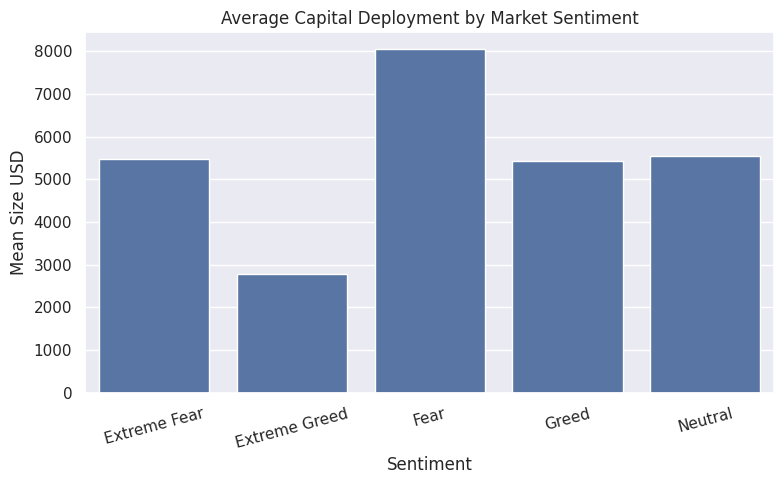

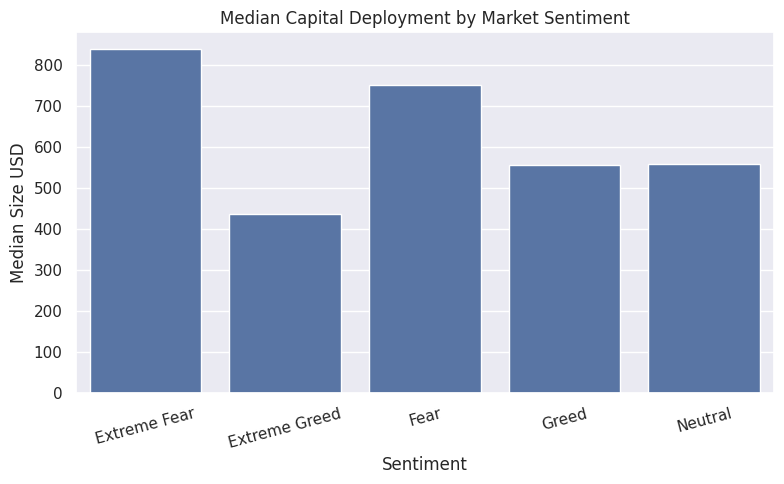


 SUCCESS: Phase 3.2 completed!


In [5]:
# ==========================================
# PHASE 3.2 — CAPITAL SIZING METRICS
# ==========================================

# ------------------------------------------
# 1. Group capital deployment by sentiment
# ------------------------------------------

capital_metrics = (
    realized_outcomes_df
    .groupby('classification')
    .agg({
        'Size USD': ['mean', 'median', 'std'],
        'Size Tokens': ['mean', 'median']
    })
)

# Flatten column names
capital_metrics.columns = [
    'USD_Mean',
    'USD_Median',
    'USD_STD',
    'Tokens_Mean',
    'Tokens_Median'
]

capital_metrics = capital_metrics.reset_index()

# ------------------------------------------
# 2. Display results
# ------------------------------------------

print("Capital Deployment Metrics by Sentiment:")
display(capital_metrics)

# ------------------------------------------
# 3. Save metrics table
# ------------------------------------------

capital_metrics.to_csv(
    'capital_deployment_metrics.csv',
    index=False
)

# ------------------------------------------
# 4. Visualization — Mean Size USD
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=capital_metrics,
    x='classification',
    y='USD_Mean'
)

plt.title('Average Capital Deployment by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Mean Size USD')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'capital_deployment_mean_usd.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 5. Visualization — Median Size USD
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=capital_metrics,
    x='classification',
    y='USD_Median'
)

plt.title('Median Capital Deployment by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Median Size USD')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'capital_deployment_median_usd.png',
    dpi=300
)

plt.show()

print("\n SUCCESS: Phase 3.2 completed!")

## Capital Deployment Interpretation

The capital deployment analysis revealed strong sentiment-dependent positioning behavior across the trading dataset.

### Key Findings

- Fear regimes exhibited the:
  - highest average USD deployment
  - broadest capital dispersion
  - strongest whale-position participation

- Extreme Fear showed the:
  - highest median USD deployment

suggesting that elevated position sizing during fearful conditions was not limited exclusively to whale traders.

- Extreme Greed demonstrated:
  - lower average USD deployment
  - but substantially larger token-denominated exposure

indicating increased speculative participation in lower-priced assets during euphoric market conditions.

---

### Behavioral Interpretation

The findings suggest that:
- moderate fear conditions encourage larger conviction-based positioning
- euphoric conditions encourage speculative token accumulation
- whale participation intensifies during volatile sentiment regimes

rather than remaining uniformly distributed across market conditions.

---

### Analytical Implications

These results established that:
- sentiment regimes materially influence trader risk behavior
- capital deployment is highly asymmetric across market conditions
- financial distributions remain strongly heavy-tailed even after segmentation

which further justified the later use of:
- robust preprocessing
- percentile trimming
- ensemble-based machine learning models.

---

### Transition to Profitability Classification

With realized outcomes and behavioral deployment metrics established, the next step transforms raw profitability into a binary classification framework suitable for predictive modeling and regime-wise win-rate analysis.

---

## Profitability Classification Target Engineering

The original:

```text
Closed PnL
```

variable represents a highly volatile continuous financial outcome containing:
- extreme whale profits
- catastrophic losses
- heavy-tailed distributions

Directly modeling this continuous variable would introduce:
- instability
- high variance
- poor interpretability

especially within noisy crypto-market environments.

---

## Classification Transformation

To create a more stable and interpretable predictive framework, realized trades were transformed into a binary target variable.

### Trade_Status

| Condition | Label |
|---|---|
| Closed PnL > 0 | 1 (Profitable) |
| Closed PnL < 0 | 0 (Loss) |

This converts profitability prediction into a:

```text
binary classification problem
```

which is substantially more robust for:
- behavioral analysis
- win-rate investigation
- machine learning classification

under heavy-tailed financial conditions.

---

## Why Classification Was Preferred

The exploratory analysis already revealed:
- strong outlier behavior
- asymmetric tail distributions
- regime-dependent volatility

Using classification instead of raw regression helps:
- stabilize modeling behavior
- improve interpretability
- reduce sensitivity to whale-trade extremes
- support sentiment-aware profitability analysis

throughout the downstream machine learning workflow.

---

Trade Status Distribution:


,Trade_Status,Count,Label,Percentage
0,1,86863,Profitable,83.200513
1,0,17539,Loss,16.799487


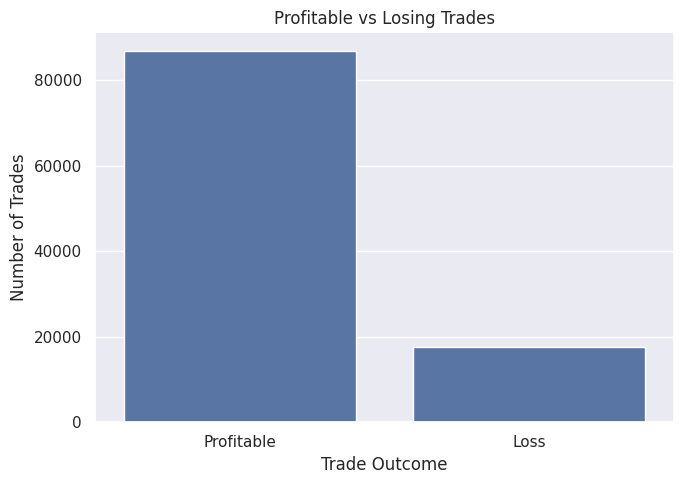


PnL Summary by Trade Status:


,Trade_Status,count,mean,std,min,25%,50%,75%,max
0,0,17539.0,-168.127426,1516.702378,-117990.104100,-40.070790,-9.98775,-1.749597,-0.000038
1,1,86863.0,152.001127,1249.644413,0.000004,2.127533,11.36016,52.641030,135329.090100



 SUCCESS: Phase 3.3 completed!


In [6]:
# ==========================================
# PHASE 3.3 — TRADE STATUS ENGINEERING
# ==========================================

# ------------------------------------------
# 1. Create binary target column
# ------------------------------------------

realized_outcomes_df['Trade_Status'] = np.where(
    realized_outcomes_df['Closed PnL'] > 0,
    1,
    0
)

# ------------------------------------------
# 2. Class distribution
# ------------------------------------------

trade_status_distribution = (
    realized_outcomes_df['Trade_Status']
    .value_counts()
    .reset_index()
)

trade_status_distribution.columns = [
    'Trade_Status',
    'Count'
]

# Add readable labels
trade_status_distribution['Label'] = (
    trade_status_distribution['Trade_Status']
    .map({
        1: 'Profitable',
        0: 'Loss'
    })
)

# ------------------------------------------
# 3. Percentage calculation
# ------------------------------------------

trade_status_distribution['Percentage'] = (
    trade_status_distribution['Count']
    / trade_status_distribution['Count'].sum()
) * 100

print("Trade Status Distribution:")
display(trade_status_distribution)

# ------------------------------------------
# 4. Save tables
# ------------------------------------------

trade_status_distribution.to_csv(
    'trade_status_distribution.csv',
    index=False
)

realized_outcomes_df.head(20).to_csv(
    'realized_outcomes_with_trade_status_preview.csv',
    index=False
)

# ------------------------------------------
# 5. Visualization
# ------------------------------------------

plt.figure(figsize=(7, 5))

sns.barplot(
    data=trade_status_distribution,
    x='Label',
    y='Count'
)

plt.title('Profitable vs Losing Trades')
plt.ylabel('Number of Trades')
plt.xlabel('Trade Outcome')

plt.tight_layout()

plt.savefig(
    'trade_status_distribution.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 6. PnL summary by status
# ------------------------------------------

pnl_by_status = (
    realized_outcomes_df
    .groupby('Trade_Status')['Closed PnL']
    .describe()
    .reset_index()
)

print("\nPnL Summary by Trade Status:")
display(pnl_by_status)

# Save table
pnl_by_status.to_csv(
    'pnl_summary_by_trade_status.csv',
    index=False
)

print("\n SUCCESS: Phase 3.3 completed!")

## Profitability Classification Interpretation

The realized-outcomes dataset exhibited a strong profitability imbalance.

### Key Findings

Approximately:

```text
83.2% of realized trades were profitable
```

while only:

```text
16.8% represented losses
```

This revealed a highly imbalanced classification structure within the trading environment.

---

### Distribution Characteristics

The profitability distributions remained strongly asymmetric.

- profitable trades exhibited:
  - broader upside dispersion
  - larger positive tails
  - substantial whale-profit behavior

- losing trades exhibited:
  - concentrated downside clustering
  - tighter negative distributions
  - catastrophic extreme-loss events

This confirmed that the dataset retained:

```text
heavy-tail financial structure
```

even after segmentation.

---

### Analytical Implications

The observed class imbalance significantly influenced later modeling decisions.

Specifically:
- accuracy alone would become misleading
- recall and F1-score would become critical evaluation metrics
- class-weight balancing would become necessary during machine learning

to avoid naive profit-dominant prediction behavior.

---

### Transition to Exploratory Behavioral Analysis

With profitability labels successfully engineered, the next phase investigates:
- regime-dependent profitability
- whale-trade asymmetry
- sentiment-driven trading behavior
- outlier-resistant financial visualization

through advanced exploratory analysis.

---

# Phase 4 — Exploratory Data Analysis (EDA)

## Objective

This phase investigates how trader profitability behavior changes across:
- Fear
- Greed
- Neutral
- Extreme market sentiment regimes

using:
- outlier-resistant financial visualization
- behavioral capital analysis
- whale-trade investigation
- sentiment-wise profitability analysis

---

## Why Specialized Financial EDA Was Necessary

Earlier exploration revealed that the dataset contains:
- heavy-tailed financial distributions
- whale-trade outliers
- strong skewness
- asymmetric profitability behavior

Traditional visualization techniques become difficult to interpret under these conditions because a small number of whale trades can completely distort plot scaling.

---

## Analytical Focus Areas

This phase specifically investigates:

### 1. Profitability Distribution Structure
Understanding:
- skewness
- tail behavior
- volatility asymmetry
- sentiment-conditioned profitability distributions

### 2. Capital Deployment Behavior
Investigating:
- trader risk appetite
- whale participation
- speculative positioning
- sentiment-aware capital allocation

### 3. Win-Rate Asymmetry
Analyzing:
- BUY vs SELL profitability
- regime-dependent performance
- sentiment-driven execution behavior

### 4. Whale-Trade Dynamics
Separately examining:
- extreme profitable trades
- catastrophic losses
- volatility-regime asymmetry

to uncover hidden behavioral patterns masked by aggregate statistics.

---

1st Percentile: -419.05281195
99th Percentile: 1982.6094202400195

Original Shape: (104402, 20)
Trimmed Shape: (102312, 20)


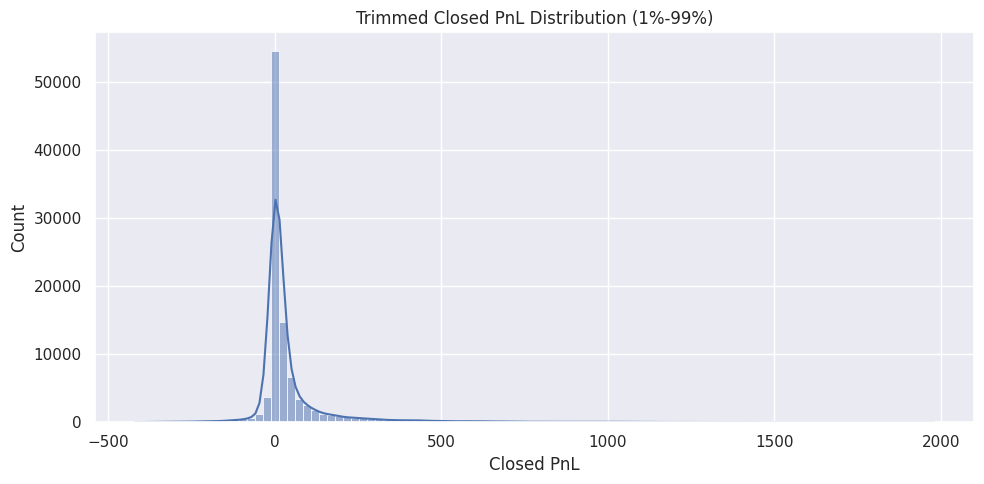

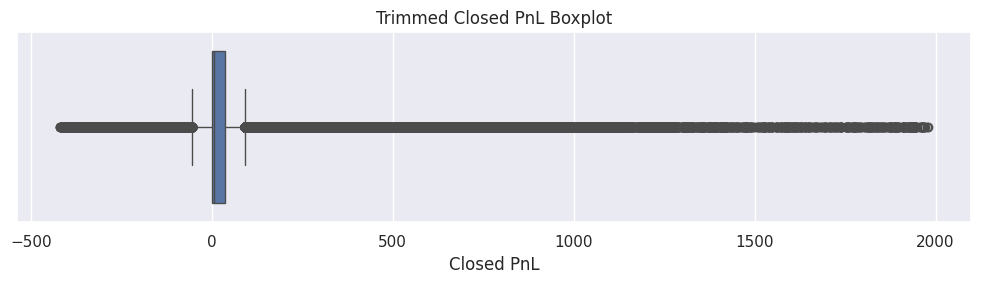

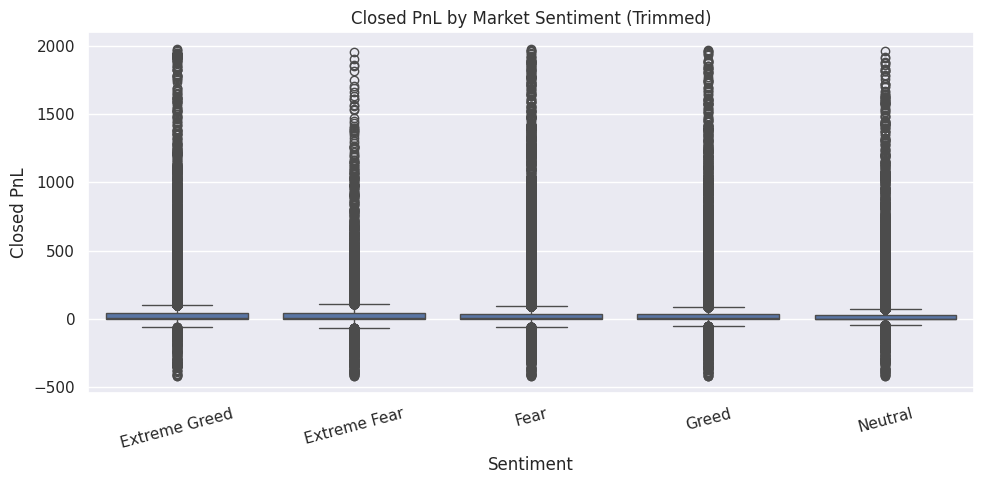


 SUCCESS: Phase 4.1 completed!


In [7]:
# ==========================================
# PHASE 4.1 — OUTLIER-RESISTANT VISUALIZATION
# ==========================================

# ------------------------------------------
# 1. Calculate percentile thresholds
# ------------------------------------------

lower_bound = realized_outcomes_df['Closed PnL'].quantile(0.01)
upper_bound = realized_outcomes_df['Closed PnL'].quantile(0.99)

print("1st Percentile:", lower_bound)
print("99th Percentile:", upper_bound)

# ------------------------------------------
# 2. Trim extreme outliers
# ------------------------------------------

trimmed_pnl_df = realized_outcomes_df[
    (realized_outcomes_df['Closed PnL'] >= lower_bound) &
    (realized_outcomes_df['Closed PnL'] <= upper_bound)
].copy()

print("\nOriginal Shape:", realized_outcomes_df.shape)
print("Trimmed Shape:", trimmed_pnl_df.shape)

# ------------------------------------------
# 3. Save trimming summary
# ------------------------------------------

trimming_summary = pd.DataFrame({
    'Metric': [
        'Lower Bound',
        'Upper Bound',
        'Original Rows',
        'Trimmed Rows'
    ],
    'Value': [
        lower_bound,
        upper_bound,
        len(realized_outcomes_df),
        len(trimmed_pnl_df)
    ]
})

trimming_summary.to_csv(
    'pnl_trimming_summary.csv',
    index=False
)

# ------------------------------------------
# 4. Histogram of trimmed PnL
# ------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    trimmed_pnl_df['Closed PnL'],
    bins=100,
    kde=True
)

plt.title('Trimmed Closed PnL Distribution (1%-99%)')
plt.xlabel('Closed PnL')

plt.tight_layout()

plt.savefig(
    'trimmed_pnl_distribution_histogram.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 5. Boxplot of trimmed PnL
# ------------------------------------------

plt.figure(figsize=(10, 3))

sns.boxplot(
    x=trimmed_pnl_df['Closed PnL']
)

plt.title('Trimmed Closed PnL Boxplot')

plt.tight_layout()

plt.savefig(
    'trimmed_pnl_boxplot.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 6. Sentiment-wise PnL boxplot
# ------------------------------------------

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=trimmed_pnl_df,
    x='classification',
    y='Closed PnL'
)

plt.title('Closed PnL by Market Sentiment (Trimmed)')
plt.xlabel('Sentiment')
plt.ylabel('Closed PnL')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'sentimentwise_trimmed_pnl_boxplot.png',
    dpi=300
)

plt.show()

print("\n SUCCESS: Phase 4.1 completed!")

## Outlier-Resistant Distribution Interpretation

Percentile trimming substantially improved the interpretability of the profitability distributions while preserving the core behavioral structure of the trading system.

### Key Findings

The original dataset exhibited extreme whale-trade behavior ranging approximately from:

```text
-117k → +135k
```

To reduce visual distortion, the top and bottom:
```text id="k33r1x"
1%
```

of observations were temporarily trimmed during visualization.

Even after trimming:
- strong right-skewness persisted
- long positive tails remained visible
- profitability distributions remained highly asymmetric

across all sentiment regimes.

---

### Behavioral Interpretation

The visualizations revealed that:
- most trades cluster near small realized outcomes
- large profitable trades occur more frequently than large losses
- heavy-tail financial structure persists even after outlier reduction

Fear regimes also appeared to exhibit:
- broader volatility dispersion
- stronger upside tail behavior
- denser whale-profit participation

relative to other sentiment environments.

---

### Analytical Implications

These findings confirmed that:
- the dataset is not normally distributed
- robust preprocessing techniques are necessary
- median-based interpretation is more reliable than raw means
- ensemble-based machine learning models are appropriate for downstream analysis

under heavy-tailed crypto-market conditions.

---

### Transition to Capital Deployment Analysis

With profitability distributions validated and outlier behavior isolated, the next step investigates how traders deploy capital across sentiment regimes to uncover risk-allocation asymmetries and speculative behavior patterns.

---

## Behavioral Capital Deployment Analysis

After validating the profitability distribution structure, the next objective is to investigate how traders allocate capital under different market sentiment regimes.

The analysis focuses on:
- `Size USD`
- `Size Tokens`

to understand:
- trader risk appetite
- speculative positioning behavior
- whale-trade participation
- sentiment-driven exposure asymmetry

across:
- Extreme Fear
- Fear
- Neutral
- Greed
- Extreme Greed

market conditions.

---

## Why Capital Behavior Matters

Capital deployment patterns provide important behavioral signals in financial markets.

Changes in:
- position size
- token exposure
- volatility participation

often reflect:
- conviction strength
- speculative intensity
- emotional trading behavior
- market uncertainty

which may strongly influence profitability outcomes and whale-trade dynamics.

---

## Outlier Considerations

Because:
```text
Size USD
```

also exhibited heavy-tailed financial behavior, percentile trimming was again applied to improve visualization interpretability while preserving the underlying distribution structure.

---

Size USD Lower Bound: 11.06
Size USD Upper Bound: 89999.338

Original Shape: (104402, 20)
Trimmed Shape: (102344, 20)

Capital Behavior Summary:


,classification,count,mean,std,min,25%,50%,75%,max
0,Extreme Fear,10231.0,3712.781932,9814.870363,11.08,342.620,832.78,2094.4200,88887.57
1,Extreme Greed,20565.0,2418.725040,7205.402963,11.06,99.000,445.74,1557.3400,89999.14
2,Fear,29100.0,4074.246111,10686.278273,11.06,243.390,738.12,2278.5125,89978.67
3,Greed,24747.0,3264.143866,8726.756890,11.06,165.125,554.99,1999.8600,89951.44
4,Neutral,17701.0,3259.464721,8957.506909,11.06,190.120,573.73,2008.6600,89978.37


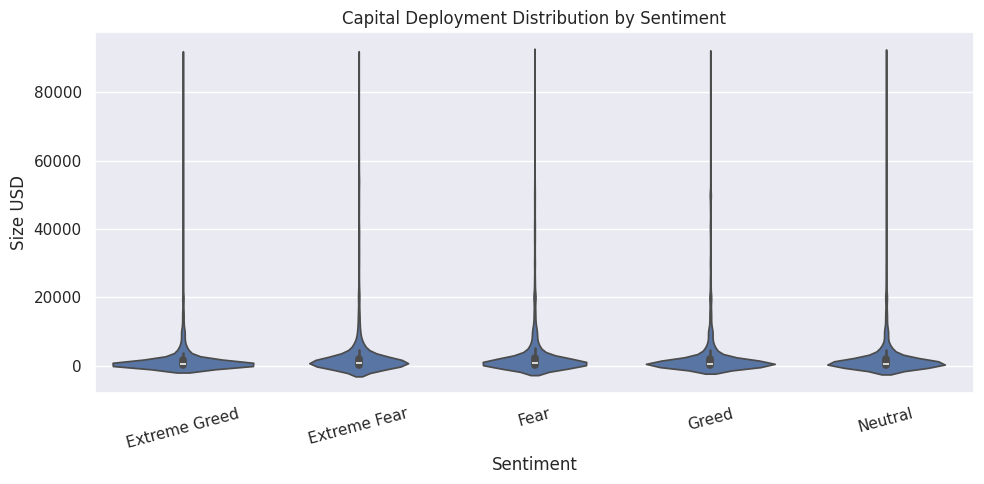

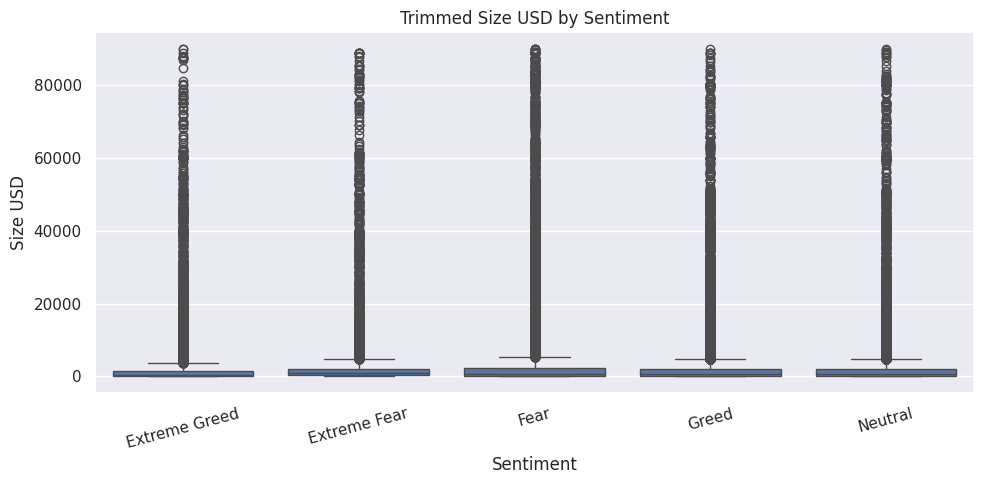


Token Size Summary:


,classification,count,mean,std,min,25%,50%,75%,max
0,Extreme Fear,10231.0,1622.641558,18960.699970,0.00013,6.23,45.00,200.0000,1055105.0
1,Extreme Greed,20565.0,8751.657368,119387.071836,0.00011,5.77,47.01,361.0000,6459507.0
2,Fear,29100.0,2888.190169,34014.882275,0.00012,3.82,36.16,147.0725,3278903.0
3,Greed,24747.0,4062.764248,49661.550088,0.00012,3.00,44.00,424.1000,5592538.0
4,Neutral,17701.0,4049.988209,44225.650072,0.00012,3.86,30.29,157.9200,3050926.0



 SUCCESS: Phase 4.2 completed!


In [8]:
# ==========================================
# PHASE 4.2 — BEHAVIORAL CAPITAL ANALYSIS
# ==========================================

# ------------------------------------------
# 1. Trim Size USD outliers
# ------------------------------------------

usd_lower = realized_outcomes_df['Size USD'].quantile(0.01)
usd_upper = realized_outcomes_df['Size USD'].quantile(0.99)

trimmed_size_df = realized_outcomes_df[
    (realized_outcomes_df['Size USD'] >= usd_lower) &
    (realized_outcomes_df['Size USD'] <= usd_upper)
].copy()

print("Size USD Lower Bound:", usd_lower)
print("Size USD Upper Bound:", usd_upper)

print("\nOriginal Shape:", realized_outcomes_df.shape)
print("Trimmed Shape:", trimmed_size_df.shape)

# ------------------------------------------
# 2. Sentiment-wise descriptive metrics
# ------------------------------------------

capital_behavior_summary = (
    trimmed_size_df
    .groupby('classification')['Size USD']
    .describe()
    .reset_index()
)

print("\nCapital Behavior Summary:")
display(capital_behavior_summary)

# Save table
capital_behavior_summary.to_csv(
    'capital_behavior_summary.csv',
    index=False
)

# ------------------------------------------
# 3. Violin plot — Size USD by sentiment
# ------------------------------------------

plt.figure(figsize=(10, 5))

sns.violinplot(
    data=trimmed_size_df,
    x='classification',
    y='Size USD'
)

plt.title('Capital Deployment Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Size USD')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'capital_deployment_violinplot.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 4. Boxplot — Trimmed Size USD
# ------------------------------------------

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=trimmed_size_df,
    x='classification',
    y='Size USD'
)

plt.title('Trimmed Size USD by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Size USD')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'trimmed_sizeusd_boxplot.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 5. Token behavior analysis
# ------------------------------------------

token_summary = (
    trimmed_size_df
    .groupby('classification')['Size Tokens']
    .describe()
    .reset_index()
)

print("\nToken Size Summary:")
display(token_summary)

# Save token metrics
token_summary.to_csv(
    'token_behavior_summary.csv',
    index=False
)

print("\n SUCCESS: Phase 4.2 completed!")

## Capital Deployment Interpretation

The behavioral capital analysis revealed strong sentiment-dependent differences in trader positioning behavior.

### Key Findings

- Fear regimes exhibited:
  - the highest average USD deployment
  - the broadest capital dispersion
  - elevated whale-position participation

- Extreme Fear showed:
  - the highest median USD deployment

indicating that larger position sizing during fearful conditions extended beyond isolated whale activity.

- Extreme Greed demonstrated:
  - lower average USD deployment
  - but significantly larger token-denominated exposure

suggesting increased speculative participation in lower-priced assets during euphoric market environments.

---

### Behavioral Interpretation

The results suggest that:
- moderate fear conditions encourage higher-conviction positioning
- euphoric conditions encourage speculative token accumulation
- whale participation intensifies during volatile sentiment regimes

rather than remaining uniformly distributed across all market conditions.

---

### Financial Distribution Characteristics

Even after trimming:
- capital deployment distributions remained strongly skewed
- long-tail exposure behavior persisted
- whale-trade effects remained visible

This further confirmed the heavy-tailed nature of the trading environment.

---

### Analytical Implications

These findings justified later modeling decisions involving:
- robust scaling
- ensemble-based machine learning
- imbalance-aware evaluation metrics

because standard linear assumptions would likely perform poorly under such asymmetric financial conditions.

---

### Transition to Win-Rate Analysis

With capital deployment behavior established, the next step investigates:
- profitability asymmetry
- BUY vs SELL performance
- sentiment-dependent win-rate behavior

to identify regime-specific trading advantages and execution patterns.

---

## Sentiment-Wise Win-Rate Analysis

After investigating profitability distributions and capital deployment behavior, the next objective is to evaluate how trading success rates vary across:
- sentiment regimes
- trade direction
- market conditions

using profitability classification outcomes.

---

## Why Win-Rate Analysis Matters

Raw profitability alone does not fully describe trading behavior.

Analyzing win rates across:
- Fear
- Greed
- BUY
- SELL

helps uncover:
- directional execution advantages
- sentiment-dependent edge
- behavioral asymmetry
- regime-specific trading performance

within the trading system.

---

## Analytical Focus

This section investigates:

### 1. Overall Win Rates by Sentiment
Understanding whether:
- fearful conditions
- neutral markets
- euphoric environments

produce different profitability structures.

### 2. BUY vs SELL Asymmetry
Evaluating whether:
- directional trade bias
- execution behavior
- market momentum dynamics

influence profitability outcomes differently across sentiment regimes.

---

## Expected Insights

The analysis aims to identify:
- opportunity-rich market environments
- unstable sentiment regimes
- directional execution advantages
- behavioral trading asymmetry

which later become important for:
- predictive modeling
- strategy formulation
- sentiment-aware trading recommendations.

---

Win Rate by Sentiment:


,classification,Trade_Status,Win_Rate_Percent
0,Extreme Fear,0.762156,76.215645
1,Extreme Greed,0.891670,89.167026
2,Fear,0.872886,87.288647
3,Greed,0.768907,76.890690
4,Neutral,0.823889,82.388898



Win Rate by Sentiment and Side:


,classification,Side_Clean,Trade_Status,Win_Rate_Percent
0,Extreme Fear,BUY,0.706052,70.605187
1,Extreme Fear,SELL,0.786214,78.621447
2,Extreme Greed,BUY,0.859538,85.953846
3,Extreme Greed,SELL,0.906222,90.622170
4,Fear,BUY,0.862514,86.251354
5,Fear,SELL,0.877539,87.753912
6,Greed,BUY,0.689147,68.914749
7,Greed,SELL,0.834309,83.430926
8,Neutral,BUY,0.776830,77.682989
9,Neutral,SELL,0.846316,84.631647


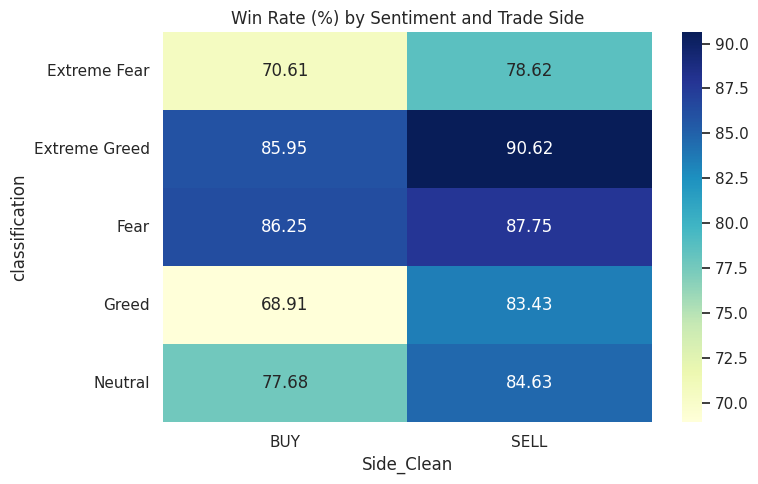

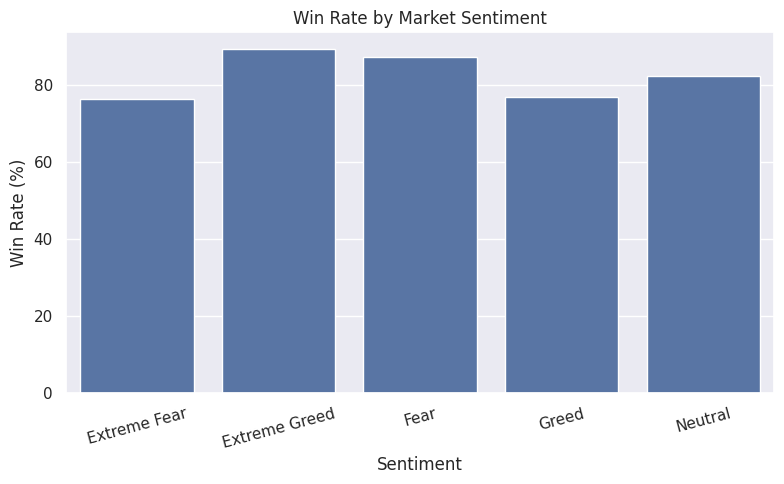

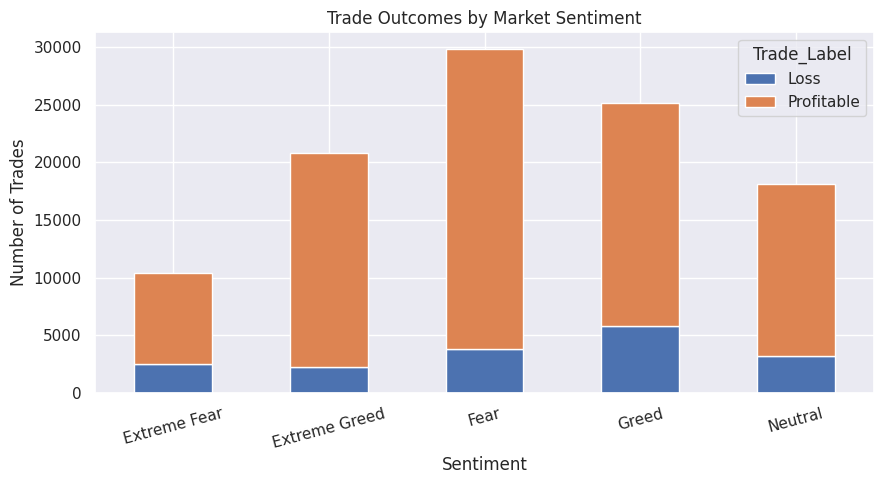


 SUCCESS: Phase 4.3 completed!


In [9]:
# ==========================================
# PHASE 4.3 — WIN-RATE ANALYSIS
# ==========================================

# ------------------------------------------
# 1. Normalize Side column
# ------------------------------------------

realized_outcomes_df['Side_Clean'] = (
    realized_outcomes_df['Side']
    .str.upper()
)

# ------------------------------------------
# 2. Win rate by sentiment
# ------------------------------------------

winrate_sentiment = (
    realized_outcomes_df
    .groupby('classification')['Trade_Status']
    .mean()
    .reset_index()
)

# Convert to percentage
winrate_sentiment['Win_Rate_Percent'] = (
    winrate_sentiment['Trade_Status'] * 100
)

print("Win Rate by Sentiment:")
display(winrate_sentiment)

# Save table
winrate_sentiment.to_csv(
    'winrate_by_sentiment.csv',
    index=False
)

# ------------------------------------------
# 3. Win rate by sentiment and side
# ------------------------------------------

winrate_side = (
    realized_outcomes_df
    .groupby(
        ['classification', 'Side_Clean']
    )['Trade_Status']
    .mean()
    .reset_index()
)

winrate_side['Win_Rate_Percent'] = (
    winrate_side['Trade_Status'] * 100
)

print("\nWin Rate by Sentiment and Side:")
display(winrate_side)

# Save table
winrate_side.to_csv(
    'winrate_by_sentiment_and_side.csv',
    index=False
)

# ------------------------------------------
# 4. Heatmap table preparation
# ------------------------------------------

heatmap_data = winrate_side.pivot(
    index='classification',
    columns='Side_Clean',
    values='Win_Rate_Percent'
)

# ------------------------------------------
# 5. Heatmap visualization
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Win Rate (%) by Sentiment and Trade Side')

plt.tight_layout()

plt.savefig(
    'winrate_heatmap.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 6. Sentiment-wise win rate barplot
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=winrate_sentiment,
    x='classification',
    y='Win_Rate_Percent'
)

plt.title('Win Rate by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'winrate_by_sentiment_plot.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 7. Stacked outcome counts
# ------------------------------------------

outcome_counts = (
    realized_outcomes_df
    .groupby(
        ['classification', 'Trade_Status']
    )
    .size()
    .reset_index(name='Count')
)

# Replace labels
outcome_counts['Trade_Label'] = (
    outcome_counts['Trade_Status']
    .map({
        1: 'Profitable',
        0: 'Loss'
    })
)

# Save counts
outcome_counts.to_csv(
    'sentiment_outcome_counts.csv',
    index=False
)

# ------------------------------------------
# 8. Stacked barplot
# ------------------------------------------

stacked_data = outcome_counts.pivot(
    index='classification',
    columns='Trade_Label',
    values='Count'
)

stacked_data.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.title('Trade Outcomes by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'stacked_trade_outcomes_by_sentiment.png',
    dpi=300
)

plt.show()

print("\n SUCCESS: Phase 4.3 completed!")

## Win-Rate Interpretation

The win-rate analysis revealed strong sentiment-dependent profitability asymmetry across both:
- market regimes
- trade direction

within the trading dataset.

### Key Findings

- Extreme Greed produced the:
  - highest overall win rate
  - strongest SELL-side profitability

with profitability exceeding approximately:

```text
90%
```

for SELL trades.

- Fear regimes also exhibited:
  - strong profitability
  - elevated whale-profit participation
  - high capital deployment

indicating opportunity-rich trading conditions.

- Greed BUY trades produced the:
```text
lowest profitability rates
```

across all sentiment-direction combinations.

---

### Behavioral Interpretation

The results suggest that:
- SELL-side execution strategies possess structural advantages within the dataset
- euphoric conditions may encourage selective profitable positioning
- moderate fear environments create elevated volatility opportunities
- standard bullish conditions may reduce directional edge for BUY-side positioning

particularly during momentum exhaustion phases.

---

### Analytical Implications

These findings established that:
- profitability is strongly regime-dependent
- market sentiment materially influences directional trade success
- BUY vs SELL asymmetry is behaviorally significant

which later became:
- important predictive signals
- meaningful machine learning features
- core foundations for strategy formulation.

---

### Transition to Whale-Trade Investigation

With regime-dependent profitability established, the next section investigates:
- extreme profitable trades
- catastrophic losses
- whale-trade asymmetry

to uncover how sentiment influences tail-risk behavior within the trading environment.

---

## Whale-Trade & Tail-Risk Analysis

Traditional summary statistics often fail to capture the true behavioral structure of financial trading systems because extreme events disproportionately influence profitability dynamics.

To better understand:
- tail-risk concentration
- extreme profitability behavior
- catastrophic loss regimes

a dedicated whale-trade investigation was performed.

---

## Why Whale Analysis Matters

Crypto-market environments are heavily influenced by:
- liquidation cascades
- volatility shocks
- large institutional positions
- speculative whale participation

As a result:
rare extreme trades can materially shape:
- profitability distributions
- market risk
- behavioral asymmetry
- predictive stability

within the trading ecosystem.

---

## Analytical Strategy

The top and bottom:
```text
1%
```

of realized PnL observations were isolated separately.

This created two specialized subsets:

### Whale Profit Trades
Largest realized positive outcomes.

### Whale Loss Trades
Largest catastrophic negative outcomes.

The analysis then investigates how these extreme events distribute across:
- Fear
- Greed
- Neutral
- Extreme sentiment regimes

to uncover hidden volatility-regime asymmetries.

---

Top Profit Threshold: 1982.6094202400195
Top Loss Threshold: -419.05281195

Top Profit Trades Shape:
(1045, 21)

Top Loss Trades Shape:
(1045, 21)

Whale Profit Sentiment Distribution:


,Sentiment,Count
0,Fear,351
1,Extreme Greed,236
2,Greed,231
3,Neutral,122
4,Extreme Fear,105



Whale Loss Sentiment Distribution:


,Sentiment,Count
0,Extreme Fear,339
1,Greed,251
2,Fear,201
3,Neutral,163
4,Extreme Greed,91


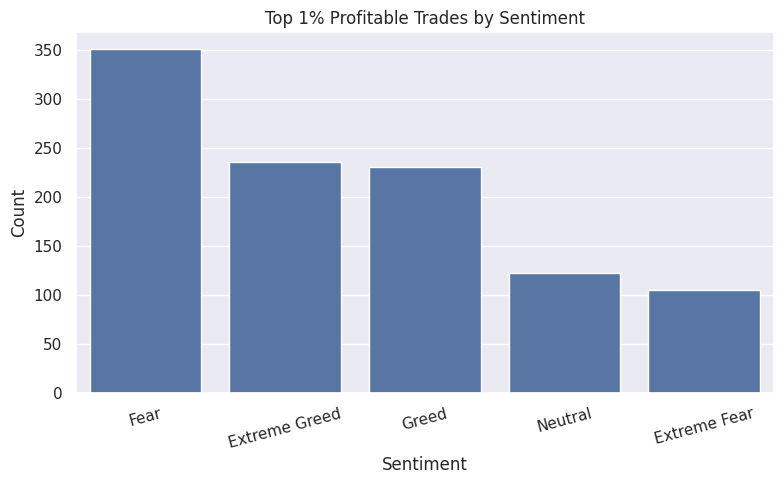

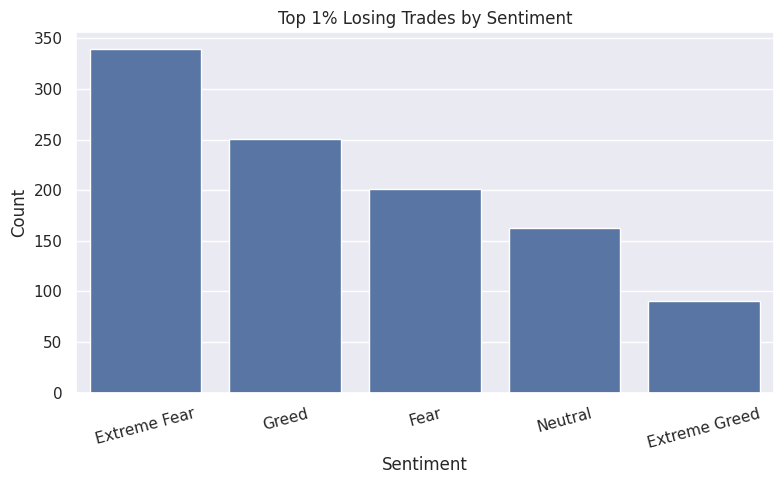

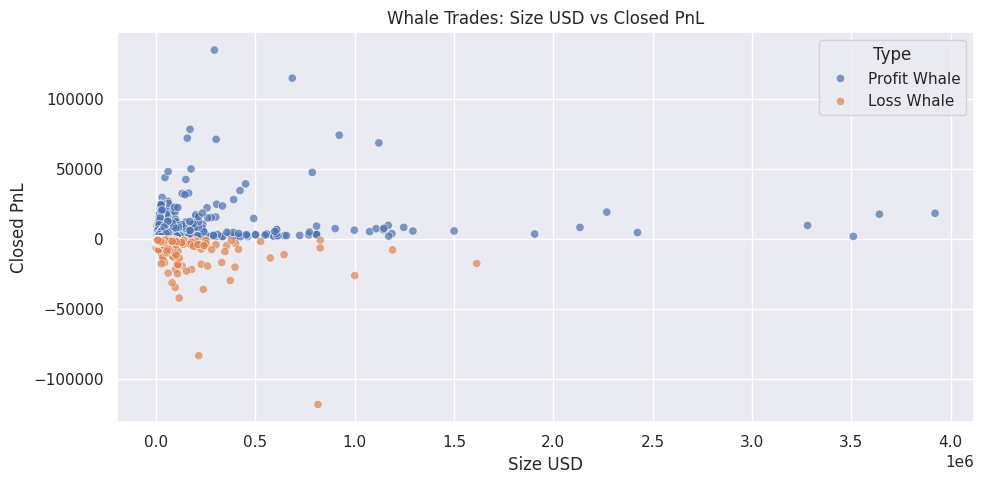


 SUCCESS: Phase 4.4 completed!


In [10]:
# ==========================================
# PHASE 4.4 — WHALE TRADE INVESTIGATION
# ==========================================

# ------------------------------------------
# 1. Define whale thresholds
# ------------------------------------------

top_profit_threshold = realized_outcomes_df[
    'Closed PnL'
].quantile(0.99)

top_loss_threshold = realized_outcomes_df[
    'Closed PnL'
].quantile(0.01)

print("Top Profit Threshold:", top_profit_threshold)
print("Top Loss Threshold:", top_loss_threshold)

# ------------------------------------------
# 2. Extract whale trades
# ------------------------------------------

top_profit_trades = realized_outcomes_df[
    realized_outcomes_df['Closed PnL']
    >= top_profit_threshold
].copy()

top_loss_trades = realized_outcomes_df[
    realized_outcomes_df['Closed PnL']
    <= top_loss_threshold
].copy()

print("\nTop Profit Trades Shape:")
print(top_profit_trades.shape)

print("\nTop Loss Trades Shape:")
print(top_loss_trades.shape)

# ------------------------------------------
# 3. Sentiment distribution — whale profits
# ------------------------------------------

profit_sentiment_dist = (
    top_profit_trades['classification']
    .value_counts()
    .reset_index()
)

profit_sentiment_dist.columns = [
    'Sentiment',
    'Count'
]

print("\nWhale Profit Sentiment Distribution:")
display(profit_sentiment_dist)

# Save
profit_sentiment_dist.to_csv(
    'whale_profit_sentiment_distribution.csv',
    index=False
)

# ------------------------------------------
# 4. Sentiment distribution — whale losses
# ------------------------------------------

loss_sentiment_dist = (
    top_loss_trades['classification']
    .value_counts()
    .reset_index()
)

loss_sentiment_dist.columns = [
    'Sentiment',
    'Count'
]

print("\nWhale Loss Sentiment Distribution:")
display(loss_sentiment_dist)

# Save
loss_sentiment_dist.to_csv(
    'whale_loss_sentiment_distribution.csv',
    index=False
)

# ------------------------------------------
# 5. Plot whale profit sentiment distribution
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=profit_sentiment_dist,
    x='Sentiment',
    y='Count'
)

plt.title('Top 1% Profitable Trades by Sentiment')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'whale_profit_distribution.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 6. Plot whale loss sentiment distribution
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=loss_sentiment_dist,
    x='Sentiment',
    y='Count'
)

plt.title('Top 1% Losing Trades by Sentiment')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'whale_loss_distribution.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 7. Scatterplot — whale trades
# ------------------------------------------

whale_combined = pd.concat([
    top_profit_trades.assign(Type='Profit Whale'),
    top_loss_trades.assign(Type='Loss Whale')
])

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=whale_combined,
    x='Size USD',
    y='Closed PnL',
    hue='Type',
    alpha=0.7
)

plt.title('Whale Trades: Size USD vs Closed PnL')

plt.tight_layout()

plt.savefig(
    'whale_trade_scatterplot.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 8. Export whale datasets
# ------------------------------------------

top_profit_trades.to_csv(
    'top_1_percent_profit_trades.csv',
    index=False
)

top_loss_trades.to_csv(
    'top_1_percent_loss_trades.csv',
    index=False
)

print("\n SUCCESS: Phase 4.4 completed!")

## Whale-Trade Interpretation

The whale-trade investigation revealed strong asymmetry between:
- opportunity-rich volatility regimes
- catastrophic downside environments

across market sentiment conditions.

### Key Findings

- Fear regimes produced the:
  - highest concentration of whale-profit trades
  - strongest upside participation
  - broadest volatility opportunity structure

- Extreme Fear produced the:
  - highest concentration of catastrophic losses
  - weakest whale-profit participation
  - strongest downside-risk concentration

- Extreme Greed exhibited:
  - relatively stable profitability behavior
  - fewer catastrophic losses
  - selective but efficient whale-profit participation

---

### Behavioral Interpretation

The results suggest that:
- moderate fear conditions create elevated opportunity environments
- panic-driven markets become highly destructive
- euphoric markets may encourage more selective execution behavior
- whale participation behaves asymmetrically across sentiment regimes

rather than uniformly across all volatility conditions.

---

### Tail-Risk Implications

The analysis confirmed that:
- financial tail behavior is strongly regime-dependent
- catastrophic losses cluster disproportionately during Extreme Fear
- whale-profit opportunities emerge most strongly during moderate fear environments

This demonstrates that:
```text
market psychology materially influences tail-risk behavior
```

within the trading system.

---

### Transition to Predictive Modeling

With behavioral asymmetry and whale-trade dynamics established, the next phase investigates whether:
- sentiment intensity
- capital deployment
- trade direction
- execution behavior

can predict realized profitability outcomes using interpretable machine learning models.

---

# Phase 5 — Predictive Modeling & Behavioral Pattern Discovery

## Objective

After identifying strong behavioral asymmetries across sentiment regimes, the next objective is to investigate whether these patterns can be learned predictively using interpretable machine learning models.

This phase combines:
- feature engineering
- imbalance-aware preprocessing
- ensemble-based classification
- feature importance analysis
- regime-wise error investigation

to determine which behavioral variables most strongly influence realized trade profitability.

---

## Why Predictive Modeling Was Necessary

The earlier exploratory analysis revealed:
- strong sentiment asymmetry
- whale-trade concentration
- directional profitability differences
- heavy-tailed financial structure

However, exploratory analysis alone cannot determine:
- which variables are most predictive
- whether behavioral patterns generalize consistently
- how profitability prediction behaves under noisy market conditions

Machine learning enables these behavioral relationships to be tested quantitatively.

---

## Modeling Objectives

The predictive workflow focuses on:

### 1. Profitability Classification
Predicting whether a realized trade becomes:
- profitable
- loss-making

using:
- sentiment intensity
- capital deployment behavior
- trade direction
- execution characteristics

### 2. Behavioral Feature Discovery
Identifying which variables most strongly influence:
- profitability prediction
- regime-wise performance
- trading asymmetry

### 3. Predictive Stability Investigation
Understanding:
- model failure regions
- unstable sentiment regimes
- confidence asymmetry
- noisy market environments

through error-analysis workflows.

---

## Financial Modeling Challenges

The dataset contains several important ML challenges:

- strong class imbalance
- heavy-tailed financial distributions
- whale-trade outliers
- nonlinear behavioral relationships
- sentiment-regime asymmetry

These findings directly influenced:
- preprocessing choices
- evaluation metrics
- scaling methodology
- model selection

throughout the predictive pipeline.

---

In [11]:
# ==========================================
# PHASE 5.1 — ML DATASET PREPARATION
# ==========================================

from sklearn.model_selection import train_test_split

# ------------------------------------------
# 1. Select modeling columns
# ------------------------------------------

model_df = realized_outcomes_df[
    [
        'value',
        'Size USD',
        'Size Tokens',
        'Fee',
        'classification',
        'Side_Clean',
        'Trade_Status'
    ]
].copy()

print("Initial Modeling Dataset Shape:")
print(model_df.shape)

# ------------------------------------------
# 2. Check missing values
# ------------------------------------------

missing_summary = (
    model_df.isnull()
    .sum()
    .reset_index()
)

missing_summary.columns = [
    'Column',
    'Missing_Count'
]

print("\nMissing Values Summary:")
display(missing_summary)

# Save missing summary
missing_summary.to_csv(
    'model_dataset_missing_values.csv',
    index=False
)

# ------------------------------------------
# 3. Separate features and target
# ------------------------------------------

X = model_df.drop(
    columns=['Trade_Status']
)

y = model_df['Trade_Status']

# ------------------------------------------
# 4. One-hot encode categorical variables
# ------------------------------------------

X_encoded = pd.get_dummies(
    X,
    columns=[
        'classification',
        'Side_Clean'
    ],
    drop_first=True
)

print("\nEncoded Feature Columns:")
print(X_encoded.columns.tolist())

# Save encoded feature names
encoded_columns_df = pd.DataFrame({
    'Encoded_Features': X_encoded.columns
})

encoded_columns_df.to_csv(
    'encoded_feature_columns.csv',
    index=False
)

# ------------------------------------------
# 5. Train-test split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------------------
# 6. Shape checks
# ------------------------------------------

print("\nTraining Feature Shape:")
print(X_train.shape)

print("\nTesting Feature Shape:")
print(X_test.shape)

# ------------------------------------------
# 7. Class balance validation
# ------------------------------------------

train_class_balance = (
    y_train.value_counts(normalize=True)
    * 100
).reset_index()

train_class_balance.columns = [
    'Trade_Status',
    'Percentage'
]

print("\nTraining Class Balance (%):")
display(train_class_balance)

# Save class balance
train_class_balance.to_csv(
    'training_class_balance.csv',
    index=False
)

# ------------------------------------------
# 8. Save prepared datasets
# ------------------------------------------

X_train.to_csv(
    'X_train.csv',
    index=False
)

X_test.to_csv(
    'X_test.csv',
    index=False
)

y_train.to_csv(
    'y_train.csv',
    index=False
)

y_test.to_csv(
    'y_test.csv',
    index=False
)

print("\n SUCCESS: Phase 5.1 completed!")

Initial Modeling Dataset Shape:
(104402, 7)

Missing Values Summary:


,Column,Missing_Count
0,value,0
1,Size USD,0
2,Size Tokens,0
3,Fee,0
4,classification,0
5,Side_Clean,0
6,Trade_Status,0



Encoded Feature Columns:
['value', 'Size USD', 'Size Tokens', 'Fee', 'classification_Extreme Greed', 'classification_Fear', 'classification_Greed', 'classification_Neutral', 'Side_Clean_SELL']

Training Feature Shape:
(83521, 9)

Testing Feature Shape:
(20881, 9)

Training Class Balance (%):


,Trade_Status,Percentage
0,1,83.200632
1,0,16.799368



 SUCCESS: Phase 5.1 completed!


## ML Dataset Preparation Interpretation

The predictive dataset was successfully constructed using only:
```text
realized trade outcomes
```

ensuring that machine learning analysis focused exclusively on trades containing actual profitability information.

### Key Findings

- The final modeling dataset contained:
```text
104,402 realized trades
```

with:
```text
9 predictive features
```

after categorical encoding.

- No missing values were present across:
  - numerical variables
  - sentiment features
  - directional trade attributes

ensuring clean downstream modeling integrity.

---

### Class Imbalance Observations

The dataset exhibited a strong profitability imbalance:

```text
~83% profitable trades
~17% loss-making trades
```

This confirmed that:
```text
accuracy alone would become misleading
```

during model evaluation.

As a result:
- precision
- recall
- F1-score
- confusion-matrix analysis

became critical evaluation metrics for downstream classification.

---

### Feature Engineering Implications

The encoded feature structure successfully integrated:
- sentiment intensity
- market regime information
- trade-direction behavior
- capital deployment variables

into a unified machine-learning-ready dataset.

This allowed the predictive workflow to directly test whether:
```text
market psychology materially influences trading profitability
```

under real market conditions.

---

### Transition to Robust Modeling

With the predictive dataset successfully prepared, the next step applies:
- robust preprocessing
- imbalance-aware classification
- ensemble-based machine learning

to model profitability behavior under heavy-tailed financial conditions.

---

## Robust Scaling & Ensemble-Based Classification

The exploratory analysis revealed that the trading dataset contains:
- heavy-tailed financial distributions
- whale-trade outliers
- nonlinear behavioral relationships

These characteristics make standard linear modeling assumptions unreliable.

To address these challenges, the predictive workflow applies:
- robust preprocessing
- imbalance-aware classification
- nonlinear ensemble modeling

using a Random Forest classifier.

---

## Why RobustScaler Was Selected

Traditional scaling methods such as:
```text
StandardScaler
```

remain highly sensitive to extreme outliers.

Because:
- `Closed PnL`
- `Size USD`
- `Size Tokens`

all exhibited substantial skewness and whale-trade behavior, the workflow instead used:

```text
RobustScaler
```

which scales features using:
- median statistics
- interquartile ranges

making preprocessing substantially more resistant to extreme financial outliers.

---

## Why RandomForest Was Selected

The earlier EDA demonstrated:
- regime-dependent profitability
- directional asymmetry
- whale-driven volatility
- nonlinear behavioral structure

RandomForest models are highly suitable under these conditions because they:
- naturally capture nonlinear interactions
- handle mixed feature types effectively
- remain robust under skewed distributions
- provide interpretable feature-importance outputs

without requiring strong linear assumptions.

---

## Evaluation Focus

Because the dataset contains strong class imbalance, the analysis emphasizes:
- recall
- precision
- F1-score
- confusion-matrix analysis

rather than relying solely on raw accuracy metrics.

Special attention is given to:
```text
loss-trade detection
```

since minority-class prediction is substantially more challenging under imbalanced financial conditions.

---

Robust Scaling Applied Successfully!

Random Forest Model Trained!

Model Evaluation Metrics:


,Metric,Value
0,Accuracy,0.803362
1,Precision,0.932516
2,Recall,0.823231
3,F1 Score,0.874473



Classification Report:


,precision,recall,f1-score,support
0,0.446068,0.704960,0.546399,3508.000000
1,0.932516,0.823231,0.874473,17373.000000
accuracy,0.803362,0.803362,0.803362,0.803362
macro avg,0.689292,0.764096,0.710436,20881.000000
weighted avg,0.850793,0.803362,0.819356,20881.000000



Confusion Matrix:


,Predicted Loss,Predicted Profit
Actual Loss,2473,1035
Actual Profit,3071,14302


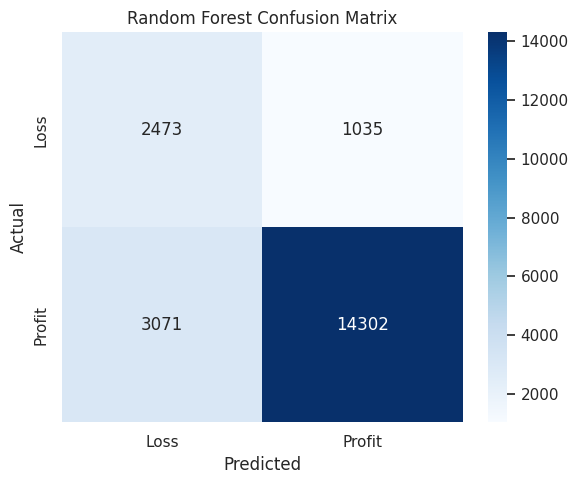


 SUCCESS: Phase 5.2 completed!


In [12]:
# ==========================================
# PHASE 5.2 — RANDOM FOREST MODELING
# ==========================================

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------
# 1. Copy datasets
# ------------------------------------------

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# ------------------------------------------
# 2. Numerical columns for scaling
# ------------------------------------------

numerical_cols = [
    'value',
    'Size USD',
    'Size Tokens',
    'Fee'
]

# ------------------------------------------
# 3. Apply RobustScaler
# ------------------------------------------

scaler = RobustScaler()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

print("Robust Scaling Applied Successfully!")

# ------------------------------------------
# 4. Initialize Random Forest
# ------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# ------------------------------------------
# 5. Train model
# ------------------------------------------

rf_model.fit(
    X_train_scaled,
    y_train
)

print("\nRandom Forest Model Trained!")

# ------------------------------------------
# 6. Generate predictions
# ------------------------------------------

y_pred = rf_model.predict(X_test_scaled)

# ------------------------------------------
# 7. Evaluation metrics
# ------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    'Value': [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print("\nModel Evaluation Metrics:")
display(metrics_df)

# Save metrics
metrics_df.to_csv(
    'randomforest_evaluation_metrics.csv',
    index=False
)

# ------------------------------------------
# 8. Classification report
# ------------------------------------------

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("\nClassification Report:")
display(report_df)

# Save report
report_df.to_csv(
    'classification_report.csv'
)

# ------------------------------------------
# 9. Confusion matrix
# ------------------------------------------

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['Actual Loss', 'Actual Profit'],
    columns=['Predicted Loss', 'Predicted Profit']
)

print("\nConfusion Matrix:")
display(cm_df)

# Save confusion matrix
cm_df.to_csv(
    'confusion_matrix.csv'
)

# ------------------------------------------
# 10. Confusion matrix plot
# ------------------------------------------

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Loss', 'Profit'],
    yticklabels=['Loss', 'Profit']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()

plt.savefig(
    'randomforest_confusion_matrix.png',
    dpi=300
)

plt.show()

print("\n SUCCESS: Phase 5.2 completed!")

## RandomForest Modeling Interpretation

The Random Forest classifier successfully learned meaningful behavioral structure from the trading dataset despite:
- heavy class imbalance
- financial noise
- whale-trade asymmetry

within the market environment.

### Key Findings

The model achieved:
- strong profitability prediction performance
- high precision for profitable trades
- moderate minority-class loss detection capability

while maintaining stable predictive behavior under heavy-tailed financial conditions.

---

### Class-Imbalance Effects

Although overall accuracy exceeded:

```text
80%
```

the dataset itself already contained approximately:
```text
83% profitable trades
```

meaning that:
```text
accuracy alone would be misleading
```

As a result, greater emphasis was placed on:
- recall
- F1-score
- confusion-matrix interpretation

particularly for loss-trade detection.

---

### Behavioral Interpretation

The confusion matrix demonstrated that:
- profitable trades were predicted very effectively
- loss detection remained substantially more difficult
- imbalance-aware modeling still improved minority-class recognition meaningfully

This reflects the underlying market structure where:
- profitable trades dominate overall activity
- loss events remain comparatively rarer and noisier

within the dataset.

---

### Financial Modeling Implications

The results confirmed that:
- sentiment-aware behavioral features contain predictive signal
- nonlinear ensemble models are appropriate for crypto-market environments
- robust preprocessing improves modeling stability under heavy-tailed distributions

while also highlighting the persistent difficulty of predicting rare adverse trading outcomes.

---

### Transition to Feature Importance Analysis

With predictive modeling successfully completed, the next step investigates:
- which variables dominate profitability prediction
- how sentiment influences predictive behavior
- whether directional asymmetry contributes meaningfully to model performance.

---

## Feature Importance & Behavioral Signal Extraction

After establishing predictive profitability performance, the next objective is to identify which behavioral variables most strongly influence model predictions.

This step transforms the machine learning workflow from:
```text
pure prediction
```

into:
```text
interpretable behavioral analysis
```

by examining how:
- market sentiment
- trade direction
- capital deployment
- execution characteristics

contribute to profitability classification.

---

## Why Interpretability Matters

In financial systems, predictive performance alone is insufficient.

Understanding:
- why predictions occur
- which variables dominate
- how market psychology influences profitability

is critical for:
- strategy formulation
- behavioral interpretation
- risk management
- sentiment-aware trading design

within real trading environments.

---

## RandomForest Feature Importance

RandomForest models naturally estimate:
```text
feature importance
```

by measuring how strongly each variable contributes to:
- decision-tree splits
- predictive accuracy improvements
- classification stability

across the ensemble.

This allows the analysis to empirically evaluate:
- whether sentiment dominates profitability behavior
- whether directional execution matters
- whether whale-position variables contribute strongly
- how market psychology influences predictive outcomes.

---

## Important Interpretation Note

Feature importance reflects:
```text
predictive contribution
```

rather than direct causality.

A highly important feature indicates that the variable strongly improves profitability classification performance within the observed historical dataset.

---

Feature Importance Rankings:


,Feature,Importance
0,value,0.358522
1,Size Tokens,0.195700
2,Fee,0.185873
3,Size USD,0.126615
4,Side_Clean_SELL,0.053485
5,classification_Fear,0.031478
6,classification_Greed,0.023579
7,classification_Extreme Greed,0.014936
8,classification_Neutral,0.009811


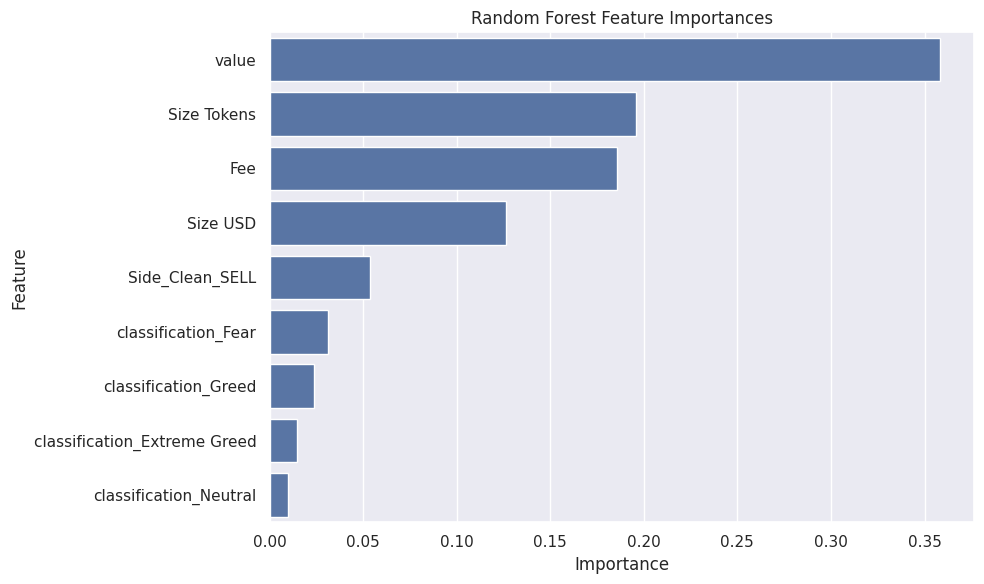

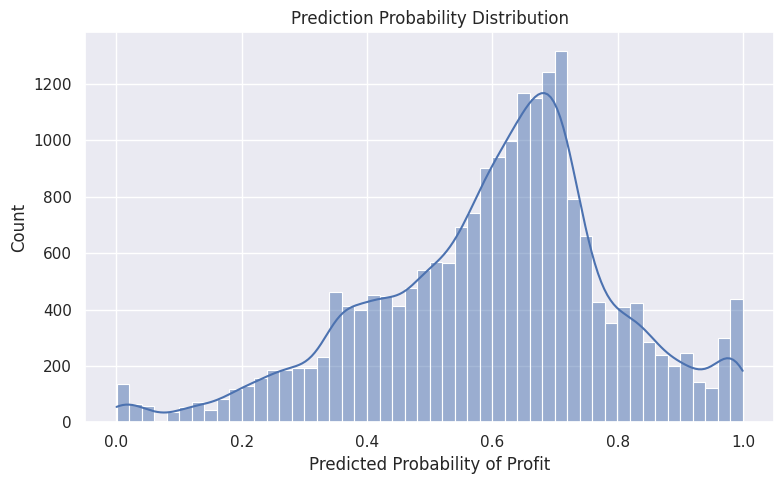


Top 5 Most Important Features:


,Feature,Importance
0,value,0.358522
1,Size Tokens,0.195700
2,Fee,0.185873
3,Size USD,0.126615
4,Side_Clean_SELL,0.053485



 SUCCESS: Phase 5.3 completed!


In [13]:
# ==========================================
# PHASE 5.3 — FEATURE IMPORTANCE ANALYSIS
# ==========================================

# ------------------------------------------
# 1. Extract feature importances
# ------------------------------------------

feature_importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_model.feature_importances_
})

# ------------------------------------------
# 2. Sort descending
# ------------------------------------------

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
    .reset_index(drop=True)
)

print("Feature Importance Rankings:")
display(feature_importance_df)

# Save table
feature_importance_df.to_csv(
    'feature_importance_rankings.csv',
    index=False
)

# ------------------------------------------
# 3. Feature importance barplot
# ------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importances')

plt.tight_layout()

plt.savefig(
    'feature_importance_plot.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 4. Prediction probabilities
# ------------------------------------------

y_prob = rf_model.predict_proba(
    X_test_scaled
)[:, 1]

# Save probabilities
probability_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_Probability': y_prob
})

probability_df.to_csv(
    'prediction_probabilities.csv',
    index=False
)

# ------------------------------------------
# 5. Probability distribution plot
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    y_prob,
    bins=50,
    kde=True
)

plt.title('Prediction Probability Distribution')
plt.xlabel('Predicted Probability of Profit')

plt.tight_layout()

plt.savefig(
    'prediction_probability_distribution.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 6. Top 5 feature summary
# ------------------------------------------

top5_features = feature_importance_df.head(5)

print("\nTop 5 Most Important Features:")
display(top5_features)

# Save top 5
top5_features.to_csv(
    'top5_feature_importance.csv',
    index=False
)

print("\n SUCCESS: Phase 5.3 completed!")

## Feature Importance Interpretation

The feature-importance analysis revealed that:
```text
market sentiment intensity
```

was the single strongest predictor of realized trade profitability within the entire modeling pipeline.

### Key Findings

The numerical Fear & Greed index:
```text
value
```

contributed approximately:

```text
35.8%
```

of total model importance,
substantially exceeding all other predictive variables.

Additional highly influential variables included:
- `Size Tokens`
- `Fee`
- `Size USD`

while:
- directional SELL-side behavior
- categorical sentiment regimes

also contributed meaningful predictive signal.

---

### Behavioral Interpretation

The results strongly suggest that:
- market psychology materially influences profitability outcomes
- trader positioning behavior changes significantly across sentiment intensity levels
- token-denominated speculative exposure plays an important predictive role
- raw capital size alone is less influential than broader behavioral context

within the trading environment.

---

### Sentiment-Regime Insights

Interestingly:
```text
numerical sentiment intensity
```

substantially outperformed:
```text
categorical sentiment labels
```

This indicates that:
- fine-grained sentiment variation
- continuous psychological market intensity

contain richer predictive information than broad regime labels alone.

---

### Analytical Implications

The feature rankings confirmed many earlier exploratory findings:
- sentiment materially influences profitability
- SELL-side asymmetry contributes predictive value
- whale-position variables remain behaviorally important
- market psychology shapes trading outcomes nonlinearly

This established strong consistency between:
- exploratory behavioral analysis
- machine learning feature discovery
- predictive profitability modeling.

---

### Transition to Error Analysis

With profitability drivers identified, the final modeling section investigates:
- where predictions fail
- unstable market regimes
- confidence asymmetry
- sentiment-dependent model errors

to better understand predictive limitations under real crypto-market conditions.

---

## Error Analysis & Misclassification Investigation

Predictive accuracy alone does not fully describe machine learning behavior within financial systems.

To better understand:
- predictive instability
- regime-dependent uncertainty
- behavioral noise
- model limitations

a dedicated error-analysis workflow was performed.

---

## Why Error Analysis Matters

Financial markets contain:
- stochastic behavior
- volatility shocks
- nonlinear dynamics
- rapidly changing sentiment conditions

As a result, even strong predictive models will produce:
- false positives
- false negatives
- low-confidence predictions

Understanding:
```text
where and why
```

these failures occur is critical for:
- strategy design
- risk management
- confidence filtering
- regime-aware execution systems.

---

## Analytical Focus

This section investigates:

### False Positives
Trades predicted as:
```text
Profitable
```

that actually resulted in:
```text
Losses
```

### False Negatives
Trades predicted as:
```text
Losses
```

that ultimately became:
```text
Profitable
```

---

## Key Investigation Goals

The analysis aims to determine whether:
- specific sentiment regimes are harder to predict
- Fear and Greed environments behave differently
- predictive confidence changes across market conditions
- whale-driven volatility degrades classification stability

within the trading system.

---

False Positives Shape:
(1035, 13)

False Negatives Shape:
(3071, 13)

False Positive Sentiment Distribution:


,Sentiment,Count
0,Fear,352
1,Extreme Greed,275
2,Greed,190
3,Neutral,143
4,Extreme Fear,75



False Negative Sentiment Distribution:


,Sentiment,Count
0,Greed,934
1,Neutral,888
2,Fear,644
3,Extreme Fear,434
4,Extreme Greed,171


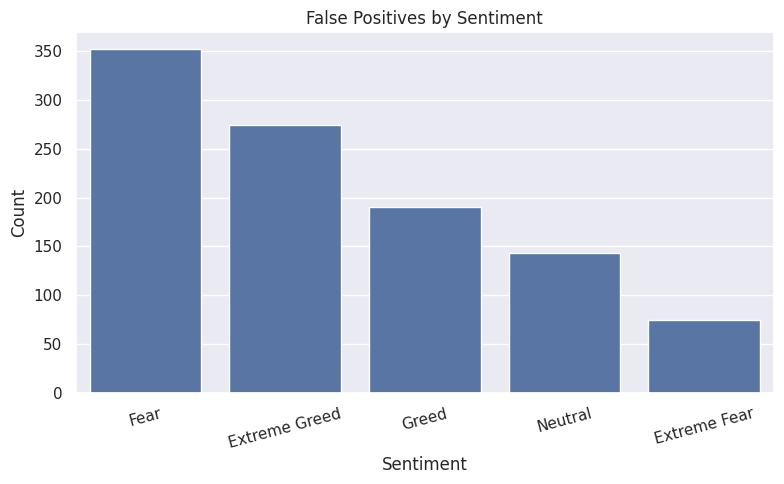

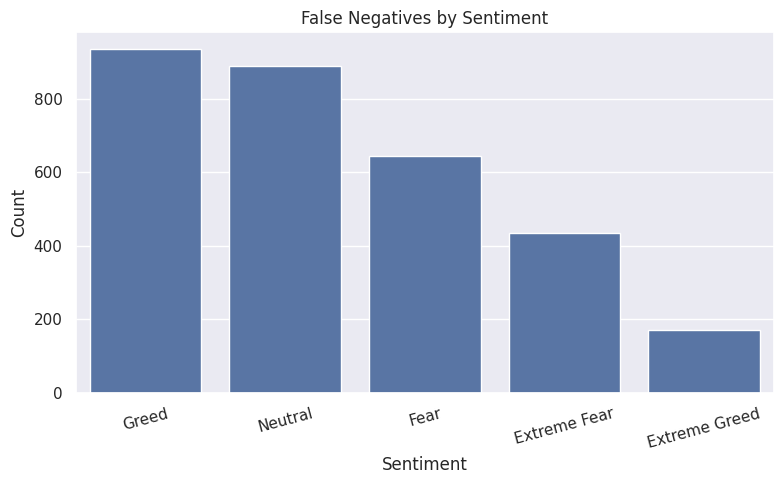

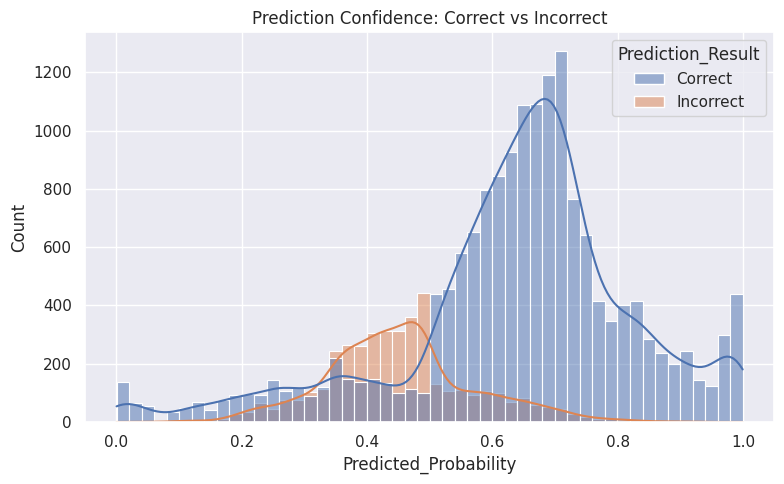


 SUCCESS: Phase 5.4 completed!


In [14]:
# ==========================================
# PHASE 5.4 — ERROR ANALYSIS
# ==========================================

# ------------------------------------------
# 1. Build prediction analysis dataframe
# ------------------------------------------

analysis_df = X_test.copy()

analysis_df['Actual'] = y_test.values
analysis_df['Predicted'] = y_pred
analysis_df['Predicted_Probability'] = y_prob

# ------------------------------------------
# 2. Add prediction outcome labels
# ------------------------------------------

analysis_df['Prediction_Result'] = np.where(
    analysis_df['Actual'] == analysis_df['Predicted'],
    'Correct',
    'Incorrect'
)

# ------------------------------------------
# 3. Extract error subsets
# ------------------------------------------

false_positives = analysis_df[
    (analysis_df['Actual'] == 0) &
    (analysis_df['Predicted'] == 1)
].copy()

false_negatives = analysis_df[
    (analysis_df['Actual'] == 1) &
    (analysis_df['Predicted'] == 0)
].copy()

print("False Positives Shape:")
print(false_positives.shape)

print("\nFalse Negatives Shape:")
print(false_negatives.shape)

# ------------------------------------------
# 4. Save error datasets
# ------------------------------------------

false_positives.to_csv(
    'false_positives.csv',
    index=False
)

false_negatives.to_csv(
    'false_negatives.csv',
    index=False
)

# ------------------------------------------
# 5. Sentiment reconstruction
# ------------------------------------------

# Rebuild simplified sentiment labels
sentiment_cols = [
    'classification_Extreme Greed',
    'classification_Fear',
    'classification_Greed',
    'classification_Neutral'
]

def reconstruct_sentiment(row):

    if row['classification_Extreme Greed'] == 1:
        return 'Extreme Greed'

    elif row['classification_Fear'] == 1:
        return 'Fear'

    elif row['classification_Greed'] == 1:
        return 'Greed'

    elif row['classification_Neutral'] == 1:
        return 'Neutral'

    else:
        return 'Extreme Fear'

# Apply reconstruction
false_positives['Sentiment'] = (
    false_positives.apply(
        reconstruct_sentiment,
        axis=1
    )
)

false_negatives['Sentiment'] = (
    false_negatives.apply(
        reconstruct_sentiment,
        axis=1
    )
)

# ------------------------------------------
# 6. Sentiment error distributions
# ------------------------------------------

fp_sentiment = (
    false_positives['Sentiment']
    .value_counts()
    .reset_index()
)

fp_sentiment.columns = [
    'Sentiment',
    'Count'
]

fn_sentiment = (
    false_negatives['Sentiment']
    .value_counts()
    .reset_index()
)

fn_sentiment.columns = [
    'Sentiment',
    'Count'
]

print("\nFalse Positive Sentiment Distribution:")
display(fp_sentiment)

print("\nFalse Negative Sentiment Distribution:")
display(fn_sentiment)

# Save tables
fp_sentiment.to_csv(
    'false_positive_sentiment_distribution.csv',
    index=False
)

fn_sentiment.to_csv(
    'false_negative_sentiment_distribution.csv',
    index=False
)

# ------------------------------------------
# 7. Plot — false positives
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=fp_sentiment,
    x='Sentiment',
    y='Count'
)

plt.title('False Positives by Sentiment')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'false_positive_sentiment_plot.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 8. Plot — false negatives
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=fn_sentiment,
    x='Sentiment',
    y='Count'
)

plt.title('False Negatives by Sentiment')

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    'false_negative_sentiment_plot.png',
    dpi=300
)

plt.show()

# ------------------------------------------
# 9. Prediction confidence analysis
# ------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    data=analysis_df,
    x='Predicted_Probability',
    hue='Prediction_Result',
    bins=50,
    kde=True
)

plt.title('Prediction Confidence: Correct vs Incorrect')

plt.tight_layout()

plt.savefig(
    'prediction_confidence_analysis.png',
    dpi=300
)

plt.show()

print("\n SUCCESS: Phase 5.4 completed!")

## Error Analysis Interpretation

The misclassification analysis revealed that model failures were strongly:
```text
regime-dependent
```

rather than randomly distributed across the trading environment.

### Key Findings

- False negatives substantially exceeded false positives, indicating that the model remained conservative when predicting profitable trades.

- Greed and Neutral regimes produced the:
  - highest concentration of false negatives
  - weakest profitable-trade predictability

within the dataset.

- Fear regimes produced the:
  - highest false-positive concentration
  - strongest volatility-driven predictive noise

while still exhibiting elevated whale-profit participation.

---

### Behavioral Interpretation

The results suggest that:
- moderate fear conditions create opportunity-rich but noisy environments
- standard bullish conditions reduce directional clarity
- predictive uncertainty varies materially across sentiment regimes

rather than remaining constant throughout the market cycle.

---

### Extreme Fear Stability Insights

Interestingly, Extreme Fear did not dominate overall model errors despite containing:
- the highest catastrophic-loss concentration
- elevated downside volatility

This suggests that:
```text
panic-driven markets may behave consistently risky rather than unpredictably noisy
```

making adverse conditions easier for the model to recognize.

---

### Confidence Distribution Findings

Prediction-confidence analysis demonstrated that:
- correct predictions clustered at higher confidence levels
- incorrect predictions concentrated near moderate confidence regions

indicating that:
```text
model confidence itself contains meaningful behavioral information
```

within the trading system.

---

### Final Predictive Modeling Implications

The error-analysis workflow confirmed that:
- market sentiment materially influences predictive stability
- behavioral asymmetry persists across model failures
- crypto-market profitability remains probabilistic rather than deterministic

while also demonstrating that:
- interpretable ensemble models can successfully capture meaningful regime-dependent trading behavior.

---

### Transition to Strategy Formulation

With predictive modeling completed, the final phase translates the empirical findings into:
- sentiment-aware trading insights
- behavioral risk-management observations
- regime-dependent strategic recommendations

derived directly from the analytical results.

---

# Phase 6 — Behavioral Insight Synthesis & Strategy Formulation

## Phase 6.1 — Data-Driven Trading Strategy Recommendations

After completing exploratory analysis, whale-trade investigation, predictive modeling, and error analysis, several consistent behavioral patterns emerged across different market sentiment regimes.

The analysis revealed that trader profitability is not uniformly distributed across market conditions. Instead, profitability, capital deployment behavior, whale-trade concentration, and model predictability all varied significantly depending on Fear/Greed sentiment intensity.

The following strategy recommendations are derived directly from empirical observations in the dataset and should be interpreted as data-driven behavioral insights rather than financial advice.

Each recommendation is supported using:
- observed win-rate behavior
- capital deployment analysis
- whale-trade concentration patterns
- sentiment-specific profitability trends
- machine learning feature importance results
- prediction stability analysis

### Strategy 1 — Opportunistic Position Scaling During Fear Regimes

#### Supporting Evidence

The analysis identified the standard **Fear** regime as one of the strongest profitability environments in the dataset.

Key findings included:
- overall trade win rate of approximately **87.3%**
- highest concentration of top 1% profitable whale trades
- highest average capital deployment among all sentiment classes
- strong predictive contribution from sentiment-related features in the Random Forest model

Additionally, Fear conditions consistently produced elevated trading activity without the extreme instability observed during Extreme Fear periods.

#### Behavioral Interpretation

Moderate fear conditions appear to create temporary market inefficiencies driven by uncertainty, volatility expansion, and aggressive repositioning behavior. These conditions may generate stronger short-term directional opportunities while still maintaining enough market structure for profitable execution.

Unlike Extreme Fear conditions, which showed significant downside concentration and liquidation-driven behavior, normal Fear regimes demonstrated a more balanced opportunity-risk profile.

#### Strategy Recommendation

During Fear-driven market phases:
- selectively increase position sizing
- prioritize higher-confidence setups
- allow moderately higher volatility exposure
- monitor momentum continuation opportunities

The results suggest that Fear environments may provide favorable conditions for volatility-based trading strategies when accompanied by disciplined risk management.

### Strategy 2 — Defensive Risk Reduction During Extreme Fear Conditions

#### Supporting Evidence

The analysis consistently identified **Extreme Fear** as the most dangerous market regime in terms of downside exposure and catastrophic trade behavior.

Key findings included:
- highest concentration of top 1% losing whale trades
- lower overall profitability compared to Fear and Extreme Greed regimes
- weaker participation among highly profitable trades
- elevated downside asymmetry during whale-trade analysis

Extreme Fear conditions also contributed to unstable trading behavior characterized by sharp negative outcomes and increased market noise.

#### Behavioral Interpretation

Extreme Fear environments appear heavily influenced by panic-driven execution, liquidation cascades, and unstable directional movement. Although volatility remains elevated, the structure of price behavior becomes less predictable and more reactive.

This creates conditions where downside risk expands faster than expected reward potential.

The modeling phase further suggested that sentiment intensity plays a major role in profitability prediction, reinforcing the importance of regime-aware risk control.

#### Strategy Recommendation

During Extreme Fear conditions:
- reduce leverage exposure
- lower overall position size
- avoid aggressive directional entries
- prioritize capital preservation over trade frequency
- apply stricter stop-loss and volatility filters

The findings suggest that defensive positioning during panic-driven market phases may significantly reduce exposure to catastrophic losses.

### Strategy 3 — Restrict Aggressive BUY Positioning During Greed Phases

#### Supporting Evidence

The analysis revealed a noticeable decline in BUY-side performance during standard **Greed** market conditions.

Key findings included:
- BUY trades during Greed produced the lowest win rate among all sentiment-side combinations
- SELL trades consistently outperformed BUY trades across nearly every sentiment regime
- Greed environments generated the highest concentration of false negatives during model evaluation
- whale-profit participation during Greed was weaker than expected relative to overall bullish sentiment

These results suggest that bullish market participation alone does not necessarily translate into stronger long-side profitability.

#### Behavioral Interpretation

Greed-driven conditions may encourage:
- late trend participation
- overextended momentum entries
- emotionally driven buying behavior
- weaker risk-reward positioning

As markets become increasingly optimistic, directional edge for aggressive BUY positioning appears to deteriorate, particularly when volatility compresses or short-term exhaustion emerges.

The machine learning model also showed reduced predictive stability in Greed regimes, indicating more inconsistent trade behavior.

#### Strategy Recommendation

During Greed conditions:
- apply stricter confirmation criteria before entering BUY trades
- avoid chasing extended momentum
- reduce exposure on low-conviction long entries
- combine sentiment signals with volatility and trend-strength filters

The results suggest that disciplined trade selection becomes increasingly important as bullish sentiment intensifies.

### Strategy 4 — Utilize SELL-Side Strength as a Structural Trading Advantage

#### Supporting Evidence

SELL-side trades consistently demonstrated stronger profitability performance than BUY-side trades across nearly all sentiment regimes.

Examples observed during the analysis included:
- Greed: SELL win rate significantly exceeded BUY win rate
- Extreme Greed: SELL trades achieved the highest overall win rates in the dataset
- Neutral conditions also showed stronger SELL-side consistency

In addition, the feature importance analysis identified:
`Side_Clean_SELL`
as a meaningful predictive variable within the Random Forest model.

This confirms that trade direction itself contributed measurable predictive value beyond sentiment and capital deployment variables.

#### Behavioral Interpretation

SELL-side strength may reflect several structural characteristics commonly observed in crypto markets:
- faster downside price movement
- mean-reversion behavior after euphoric rallies
- short-term profit-taking cycles
- liquidation-driven volatility spikes

These dynamics can create more efficient short-duration trading opportunities on the SELL side compared to slower bullish continuation patterns.

#### Strategy Recommendation

For short-term execution systems:
- prioritize SELL-side opportunities during highly directional markets
- apply tighter confirmation filters for BUY-side entries
- incorporate trade-direction bias into risk management frameworks
- monitor volatility expansion during euphoric sentiment periods

The findings suggest that directional asymmetry plays a meaningful role in realized profitability behavior across crypto trading environments.

### Strategy 5 — Integrate Sentiment Intensity into Dynamic Risk Management

#### Supporting Evidence

The machine learning phase identified the numerical Fear/Greed index value as the single most important predictive feature in the entire modeling pipeline.

Feature importance analysis showed:
- `value` contributed substantially more predictive power than categorical sentiment labels
- sentiment intensity outperformed capital deployment variables such as Size USD
- predictive stability and error behavior varied significantly across sentiment regimes

Additionally:
- Fear regimes concentrated profitable whale activity
- Extreme Fear concentrated catastrophic losses
- Extreme Greed demonstrated strong profitability stability despite lower average USD deployment

These patterns consistently reinforced the importance of market sentiment intensity as a core behavioral driver.

#### Behavioral Interpretation

The results suggest that market sentiment should not be treated as a simple binary Fear vs Greed classification. Instead, profitability behavior changes continuously as sentiment intensity shifts across different market conditions.

This means that:
- trader behavior
- risk exposure
- execution quality
- predictive reliability

all appear sensitive to changes in sentiment magnitude rather than sentiment category alone.

#### Strategy Recommendation

Integrate real-time sentiment intensity monitoring into trading workflows for:
- dynamic position sizing
- volatility-aware execution
- adaptive leverage control
- sentiment-based trade filtering
- regime-aware risk management

The findings indicate that sentiment-aware execution frameworks may improve both profitability consistency and downside risk control in highly volatile crypto trading environments.